# I-Environnement

In [1]:
# ============================================================
# STEP 1 — Environnement
# ============================================================
import os, math, time, csv, json
from pathlib import Path
from collections import defaultdict
!pip install codecarbon

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import (
    resnet18,  ResNet18_Weights,
    resnet50,  ResNet50_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
)
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, precision_score, recall_score)
import yaml

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"GPUs disponibles : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i} : {torch.cuda.get_device_name(i)} "
          f"— {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")
print(f"PyTorch : {torch.__version__}")

try:
    _eff = efficientnet_b0(weights=None)
    print("EfficientNet-B0 : disponible ✓")
    del _eff
except Exception as e:
    print(f"EfficientNet-B0 : erreur — {e}")


class Struct:
    def __init__(self, **entries):
        self.__dict__.update(entries)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 8.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 82.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 88.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 90.8 MB/s eta 0:00:00:00:01
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflic

# Config YAML + Struct

In [2]:
HMSIPS_NODE21_CONF = """
# optimisation
n_epoch: 50
B: 16
B_seq: 16
n_epoch_warmup: 10
lr: 0.0001
wd: 0.1

# dataset
n_class: 2
data_dir: '/kaggle/input/datasets/pshikk/node-21-dataset-untampered'
img_size: 1024
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 42
track_epochs: [0, 1]

# leviers VRAM / vitesse
use_checkpoint: False
ips_encode_batch: 128

# encodeur
n_chan_in: 1
pretrained: True
enc_type: 'resnet18'
n_res_blocks: 4

# grille alignée
# coarse_stride = coarse_size  → pas de chevauchement entre zones
# fine_stride   = fine_size    → pas de chevauchement entre fins
# coarse_size % fine_size == 0 → divisibilité exacte
# 1024 / 256 = 4  →  4×4 = 16 zones grossières
# 256  / 128  = 2  →  2×2 = 4 patches fins par zone
coarse_size: 256
coarse_stride: 256
fine_size: 128
fine_stride: 128
# IPS
shuffle: True
shuffle_style: 'batch'
n_token: 1
M_coarse: 4
M: 10
I: 10



# agrégateur
use_pos: False
scale_embedding: False
H: 8
D: 512
D_k: 64
D_v: 64
D_inner: 2048
attn_dropout: 0.1
dropout: 0.1

# tâches
tasks:
  task0:
    id: 0
    name: 'nodule'
    act_fn: 'softmax'
    metric:
      - accuracy
      - auc
      - f1
      - precision
      - recall
"""

hmsips_node21_conf = Struct(**yaml.safe_load(HMSIPS_NODE21_CONF))

# vérification grille alignée
assert hmsips_node21_conf.coarse_stride == hmsips_node21_conf.coarse_size
assert hmsips_node21_conf.fine_stride   == hmsips_node21_conf.fine_size
assert hmsips_node21_conf.coarse_size   % hmsips_node21_conf.fine_size == 0
assert hmsips_node21_conf.img_size      % hmsips_node21_conf.coarse_size == 0

n_coarse        = (hmsips_node21_conf.img_size    // hmsips_node21_conf.coarse_size) ** 2
n_fine_per_zone = (hmsips_node21_conf.coarse_size // hmsips_node21_conf.fine_size)   ** 2
n_cand          = hmsips_node21_conf.M_coarse * n_fine_per_zone
assert n_cand >= hmsips_node21_conf.M

print(f"NODE21 — zones grossières : {n_coarse}")
print(f"NODE21 — fins par zone    : {n_fine_per_zone}")
print(f"NODE21 — candidats fins   : {n_cand}  ({hmsips_node21_conf.M_coarse}×{n_fine_per_zone})")
print(f"NODE21 — M final          : {hmsips_node21_conf.M}")

NODE21 — zones grossières : 16
NODE21 — fins par zone    : 4
NODE21 — candidats fins   : 16  (4×4)
NODE21 — M final          : 10


# Config YAML (HMSIPS_DDR_CONF)

In [3]:
HMSIPS_DDR_CONF = """
# optimisation
n_epoch: 50
B: 16
B_seq: 16
n_epoch_warmup: 10
lr: 0.0001
wd: 0.1

# dataset
n_class: 5
data_dir: '/kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors/DDR-dataset'
img_size: 896
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 42
track_epochs: [0, 1]

# leviers VRAM / vitesse
use_checkpoint: False
ips_encode_batch: 128

# encodeur
n_chan_in: 3
pretrained: True
enc_type: 'resnet18'
n_res_blocks: 4

# grille alignée
# 896 / 224 = 4  →  4×4 = 16 zones grossières
# 224 / 112 = 2  →  2×2 = 4 patches fins par zone
coarse_size: 224
coarse_stride: 224
fine_size: 112
fine_stride: 112

# IPS
shuffle: True
shuffle_style: 'batch'
n_token: 1
M_coarse: 4
M: 10
I: 10


# agrégateur
use_pos: False
scale_embedding: False
H: 8
D: 512
D_k: 64
D_v: 64
D_inner: 2048
attn_dropout: 0.1
dropout: 0.1

# tâches
tasks:
  task0:
    id: 0
    name: 'dr_grade'
    act_fn: 'softmax'
    metric:
      - accuracy
      - kappa
      - f1
"""

hmsips_ddr_conf = Struct(**yaml.safe_load(HMSIPS_DDR_CONF))

# vérification grille alignée
assert hmsips_ddr_conf.coarse_stride == hmsips_ddr_conf.coarse_size
assert hmsips_ddr_conf.fine_stride   == hmsips_ddr_conf.fine_size
assert hmsips_ddr_conf.coarse_size   % hmsips_ddr_conf.fine_size == 0
assert hmsips_ddr_conf.img_size      % hmsips_ddr_conf.coarse_size == 0

n_coarse        = (hmsips_ddr_conf.img_size    // hmsips_ddr_conf.coarse_size) ** 2
n_fine_per_zone = (hmsips_ddr_conf.coarse_size // hmsips_ddr_conf.fine_size)   ** 2
n_cand          = hmsips_ddr_conf.M_coarse * n_fine_per_zone
assert n_cand >= hmsips_ddr_conf.M

print(f"DDR — zones grossières : {n_coarse}")
print(f"DDR — fins par zone    : {n_fine_per_zone}")
print(f"DDR — candidats fins   : {n_cand}  ({hmsips_ddr_conf.M_coarse}×{n_fine_per_zone})")
print(f"DDR — M final          : {hmsips_ddr_conf.M}")

DDR — zones grossières : 16
DDR — fins par zone    : 4
DDR — candidats fins   : 16  (4×4)
DDR — M final          : 10


# YAML RSNA pour HMSIPSNet

In [4]:
# ============================================================
# STEP 1 — Config HMSIPS RSNA
# Grille alignée : 1024 / 128 = 8×8 = 64 zones grossières
#                  128  / 64  = 2×2 = 4 patches fins par zone
# ============================================================
import yaml

HMSIPS_RSNA_CONFIG = """
# optimisation
n_epoch: 50
B: 16
B_seq: 16
n_epoch_warmup: 10
lr: 0.0001
wd: 0.1

# dataset
n_class: 2
data_dir: '/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset'
img_size: 1024
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 42
track_epochs: [0, 1]

# leviers VRAM
use_checkpoint: False
ips_encode_batch: 128

# encodeur
n_chan_in: 1
pretrained: True
enc_type: 'resnet18'
n_res_blocks: 4

# grille alignée (identique NODE21)
# 1024 / 128 = 8  → 8×8 = 64 zones grossières
# 128  / 64  = 2  → 2×2 = 4 patches fins par zone
# N_cand = M_coarse × n_fine_per_zone = 4 × 4 = 16 ≥ M=10 ✓
coarse_size: 256
coarse_stride: 256
fine_size: 128
fine_stride: 128

# IPS
shuffle: True
shuffle_style: 'batch'
n_token: 1
M_coarse: 4
M: 10
I: 10

# agrégateur
use_pos: False
scale_embedding: False
H: 8
D: 512
D_k: 64
D_v: 64
D_inner: 2048
attn_dropout: 0.1
dropout: 0.1

# tâches
tasks:
  task0:
    id: 0
    name: 'pneumonia'
    act_fn: 'softmax'
    metric:
      - accuracy
      - auc
      - f1
      - precision
      - recall
"""

hmsips_rsna_conf = Struct(**yaml.safe_load(HMSIPS_RSNA_CONFIG))

# ── Vérifications grille alignée ─────────────────────────────
assert hmsips_rsna_conf.coarse_stride == hmsips_rsna_conf.coarse_size
assert hmsips_rsna_conf.fine_stride   == hmsips_rsna_conf.fine_size
assert hmsips_rsna_conf.coarse_size   % hmsips_rsna_conf.fine_size == 0
assert hmsips_rsna_conf.img_size      % hmsips_rsna_conf.coarse_size == 0

n_coarse        = (hmsips_rsna_conf.img_size    // hmsips_rsna_conf.coarse_size) ** 2
n_fine_per_zone = (hmsips_rsna_conf.coarse_size // hmsips_rsna_conf.fine_size)   ** 2
n_cand          = hmsips_rsna_conf.M_coarse * n_fine_per_zone
assert n_cand >= hmsips_rsna_conf.M, \
    f"N_cand={n_cand} < M={hmsips_rsna_conf.M} — augmenter M_coarse"

print(f"RSNA HMSIPS — zones grossières : {n_coarse}")
print(f"RSNA HMSIPS — fins par zone    : {n_fine_per_zone}")
print(f"RSNA HMSIPS — candidats fins   : {n_cand}  "
      f"({hmsips_rsna_conf.M_coarse}×{n_fine_per_zone})")
print(f"RSNA HMSIPS — M final          : {hmsips_rsna_conf.M}")
print(f"RSNA HMSIPS — n_chan_in        : {hmsips_rsna_conf.n_chan_in}  (grayscale)")
print(f"Tasks     : {[t['name'] for t in hmsips_rsna_conf.tasks.values()]}")
print(f"Métriques : {hmsips_rsna_conf.tasks['task0']['metric']}")

RSNA HMSIPS — zones grossières : 16
RSNA HMSIPS — fins par zone    : 4
RSNA HMSIPS — candidats fins   : 16  (4×4)
RSNA HMSIPS — M final          : 10
RSNA HMSIPS — n_chan_in        : 1  (grayscale)
Tasks     : ['pneumonia']
Métriques : ['accuracy', 'auc', 'f1', 'precision', 'recall']


# Dataset

In [5]:
# ============================================================
# STEP 3 — Dataset : NODE21DatasetHMSIPS
# Identique à NODE21DatasetMSIPS :
# retourne l'image entière (1, H, W)
# Le patchifier hiérarchique est dans HMSIPSNet.ips()
# ============================================================
import hashlib
import numpy as np
import torch
import SimpleITK as sitk
from pathlib import Path
from torch.utils.data import Dataset
from torchvision import transforms

class NODE21DatasetHMSIPS(Dataset):
    """
    Classification binaire nodule (1) / pas de nodule (0).
    Retourne l'image entière normalisée (1, 1024, 1024).
    Le découpage hiérarchique est délégué à HMSIPSNet.ips().
    """

    IMG_SIZE = 1024

    @staticmethod
    def _to_split(name, seed=42):
        h = int(hashlib.md5((name + str(seed)).encode()).hexdigest(), 16)
        return 'test' if (h % 100) < 20 else 'train'

    def __init__(self, conf, train=True):
        self.tasks    = conf.tasks
        self.img_size = conf.img_size
        self.train    = train

        data_root = Path(conf.data_dir)
        proc_dir  = data_root / 'cxr_images' / 'proccessed_data' / 'images'
        orig_dir  = data_root / 'cxr_images' / 'original_data'   / 'images'

        all_samples = (
            [(f, 1) for f in sorted(proc_dir.glob('n*.mha'))] +
            [(f, 0) for f in sorted(orig_dir.glob('c*.mha'))]
        )

        split_name = 'train' if train else 'test'
        self._data = [
            (path, label) for path, label in all_samples
            if self._to_split(path.name) == split_name
        ]

        if train:
            self.aug = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(5),
            ])
        else:
            self.aug = None

        pos = sum(l for _, l in self._data)
        neg = len(self._data) - pos
        print(f"{'Train' if train else 'Test'} : "
              f"{len(self._data)} images "
              f"(pos={pos}, neg={neg})")

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        path, label = self._data[i]

        arr = sitk.GetArrayFromImage(
            sitk.ReadImage(str(path))).astype(np.float32)

        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)

        if arr.shape != (self.img_size, self.img_size):
            import torch.nn.functional as F
            t = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)
            t = F.interpolate(t, size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False)
            arr = t.squeeze().numpy()

        img = torch.from_numpy(arr).unsqueeze(0)   # (1, H, W)
        img = (img - 0.5) / 0.5                    # → [-1, 1]

        if self.aug is not None:
            img = self.aug(img)

        data_dict = {'input': img}
        for task in self.tasks.values():
            data_dict[task['name']] = label

        return data_dict


# ── Sanity check ─────────────────────────────────────────────
ds_train = NODE21DatasetHMSIPS(hmsips_node21_conf, train=True)
ds_test  = NODE21DatasetHMSIPS(hmsips_node21_conf, train=False)

sample = ds_train[0]
print(f"\nInput shape : {sample['input'].shape}")
print(f"Label       : {sample['nodule']}")
print(f"Range       : [{sample['input'].min():.3f}, "
      f"{sample['input'].max():.3f}]")

Train : 3902 images (pos=915, neg=2987)
Test : 980 images (pos=219, neg=761)

Input shape : torch.Size([1, 1024, 1024])
Label       : 1
Range       : [-1.000, 1.000]


#  DDRDatasetHMSIPS

In [6]:
# ============================================================
# STEP 8b — DDRDatasetHMSIPS + enregistrement DataFactory
# ============================================================
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class DDRDatasetHMSIPS(Dataset):
    """
    DDR — rétinopathie diabétique, 5 classes (0→4).
    Retourne l'image entière normalisée (3, img_size, img_size).
    Le découpage hiérarchique est délégué à HMSIPSNet.ips().
    Classe 5 (ungradable) exclue automatiquement.
    """

    CLASSES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

    def __init__(self, conf, train=True, split=None):
        self.tasks    = conf.tasks
        self.img_size = conf.img_size

        if split is None:
            split = 'train' if train else 'valid'
        assert split in ('train', 'valid', 'test'), \
            f"split doit être 'train', 'valid' ou 'test', reçu: {split}"
        self.split = split

        data_root  = Path(conf.data_dir) / 'DR_grading'
        label_file = data_root / f'{split}.txt'
        img_dir    = data_root / split

        self._data = []
        with open(label_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                fname, grade = parts[0], int(parts[1])
                if grade == 5:
                    continue
                img_path = img_dir / fname
                if img_path.exists():
                    self._data.append((img_path, grade))

        counts = [0] * 5
        for _, g in self._data:
            counts[g] += 1
        dist_str = ', '.join(f"C{i}={counts[i]}" for i in range(5))
        print(f"[DDRDatasetHMSIPS] split={split:5s} | "
              f"{len(self._data):5d} imgs | {dist_str}")

        if split == 'train':
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(15),
                transforms.ColorJitter(
                    brightness=0.2, contrast=0.2,
                    saturation=0.1, hue=0.05),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        path, label = self._data[i]
        img = Image.open(path).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0
        t   = torch.from_numpy(arr).permute(2, 0, 1)   # (3, H, W)
        t   = self.transform(t)
        data_dict = {'input': t}
        for task in self.tasks.values():
            data_dict[task['name']] = label
        return data_dict




# ── Sanity check ─────────────────────────────────────────────
ds_train = DDRDatasetHMSIPS(hmsips_ddr_conf, train=True)
ds_val   = DDRDatasetHMSIPS(hmsips_ddr_conf, train=False)
ds_test  = DDRDatasetHMSIPS(hmsips_ddr_conf, split='test')

sample = ds_train[0]
print(f"\nInput shape : {sample['input'].shape}")   # (3, 896, 896)
print(f"Label       : {sample['dr_grade']}")        # 0–4
print(f"Range       : [{sample['input'].min():.3f}, "
      f"{sample['input'].max():.3f}]")

labels_check = [ds_train[i]['dr_grade']
                for i in range(min(100, len(ds_train)))]
print(f"Labels uniques (100 premiers) : {sorted(set(labels_check))}")

[DDRDatasetHMSIPS] split=train |  6260 imgs | C0=3133, C1=315, C2=2238, C3=118, C4=456
[DDRDatasetHMSIPS] split=valid |  2503 imgs | C0=1253, C1=126, C2=895, C3=47, C4=182
[DDRDatasetHMSIPS] split=test  |  3759 imgs | C0=1880, C1=189, C2=1344, C3=71, C4=275

Input shape : torch.Size([3, 896, 896])
Label       : 0
Range       : [-2.118, 1.737]
Labels uniques (100 premiers) : [0]


# RSNADatasetHMSIPS.

In [7]:
# ============================================================
# STEP 2 — RSNADatasetHMSIPS
# Retourne l'image entière (1, 1024, 1024)
# Le découpage hiérarchique est délégué à HMSIPSNet.ips()
# Identique à NODE21DatasetHMSIPS — adapté pour RSNA PNG
# ============================================================
import hashlib
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms


class RSNADatasetHMSIPS(Dataset):
    """
    Classification binaire pneumonie RSNA.
    Retourne l'image entière normalisée (1, img_size, img_size).
    Le découpage hiérarchique est délégué à HMSIPSNet.ips().

    Label  : Target (0/1) après déduplication max par patientId.
    Split  : 75% train / 25% test par hash MD5 (aligné Han et al. 2022).
    """

    @staticmethod
    def _to_split(patient_id, seed=42):
        h = int(hashlib.md5(
            (str(patient_id) + str(seed)).encode()
        ).hexdigest(), 16)
        return 'test' if (h % 100) < 25 else 'train'

    def __init__(self, conf, train=True):
        self.tasks    = conf.tasks
        self.img_size = conf.img_size
        self.train    = train

        data_root = Path(conf.data_dir)
        img_dir   = data_root / 'Training' / 'Images'
        meta_path = data_root / 'stage2_train_metadata.csv'

        # ── Chargement + déduplication ───────────────────────
        df_raw   = pd.read_csv(meta_path)
        df_dedup = (df_raw
                    .groupby('patientId')['Target']
                    .max()
                    .reset_index())

        # ── Split 75/25 ──────────────────────────────────────
        split_name = 'train' if train else 'test'
        df_dedup['split'] = df_dedup['patientId'].apply(
            lambda pid: self._to_split(pid, seed=conf.seed))
        df_split = df_dedup[
            df_dedup['split'] == split_name
        ].reset_index(drop=True)

        # ── Construction liste (path, label) ─────────────────
        self._data = []
        missing    = 0
        for _, row in df_split.iterrows():
            img_path = img_dir / f"{row['patientId']}.png"
            if img_path.exists():
                self._data.append((img_path, int(row['Target'])))
            else:
                missing += 1

        pos = sum(l for _, l in self._data)
        neg = len(self._data) - pos
        print(f"{'Train' if train else 'Test '} : {len(self._data)} images "
              f"| pos={pos} ({100*pos/len(self._data):.1f}%) "
              f"| neg={neg} ({100*neg/len(self._data):.1f}%) "
              f"| ratio={neg/max(pos,1):.2f}:1"
              + (f" | ⚠ {missing} manquantes" if missing else ""))

        # ── Transforms ───────────────────────────────────────
        if train:
            self.aug = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(5),
            ])
        else:
            self.aug = None

    def __len__(self):
        return len(self._data)

    def _load_image(self, path):
        """Charge PNG grayscale → tensor [1, img_size, img_size] float32."""
        img = Image.open(path).convert('L')
        if img.size != (self.img_size, self.img_size):
            img = img.resize(
                (self.img_size, self.img_size), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0
        return torch.from_numpy(arr).unsqueeze(0)   # [1, H, W]

    def __getitem__(self, i):
        path, label = self._data[i]

        img = self._load_image(path)        # [1, 1024, 1024]  ∈ [0, 1]
        img = (img - 0.5) / 0.5            # → [-1, 1]

        if self.aug is not None:
            img = self.aug(img)

        data_dict = {'input': img}
        for task in self.tasks.values():
            data_dict[task['name']] = label
        return data_dict


# ── Sanity check ─────────────────────────────────────────────
ds_train_hm = RSNADatasetHMSIPS(hmsips_rsna_conf, train=True)
ds_test_hm  = RSNADatasetHMSIPS(hmsips_rsna_conf, train=False)

sample = ds_train_hm[0]
print(f"\nInput shape : {sample['input'].shape}")   # (1, 1024, 1024)
print(f"Label       : {sample['pneumonia']}")        # 0 ou 1
print(f"Range       : [{sample['input'].min():.3f}, "
      f"{sample['input'].max():.3f}]")               # [-1, 1]

labels_check = [ds_train_hm[i]['pneumonia']
                for i in range(min(200, len(ds_train_hm)))]
print(f"Labels uniques (200 premiers) : {sorted(set(labels_check))}")

Train : 20005 images | pos=4509 (22.5%) | neg=15496 (77.5%) | ratio=3.44:1
Test  : 6679 images | pos=1503 (22.5%) | neg=5176 (77.5%) | ratio=3.44:1

Input shape : torch.Size([1, 1024, 1024])
Label       : 0
Range       : [-1.000, 0.922]
Labels uniques (200 premiers) : [0, 1]


 # DataFactory

In [8]:
# ============================================================
# STEP 4 — DataFactory
# ============================================================
from torch.utils.data import DataLoader

class DataFactory:
    _registry = {
        "hmsips_node21": NODE21DatasetHMSIPS,
    }

    def __init__(self, conf, dataset="hmsips_node21"):
        if dataset not in self._registry:
            raise ValueError(
                f"Dataset '{dataset}' inconnu.\n"
                f"Disponibles : {list(self._registry.keys())}")

        self.conf    = conf
        self.dataset = dataset
        cls          = self._registry[dataset]

        self.train_data = cls(conf, train=True)
        self.test_data  = cls(conf, train=False)

        print(f"DataFactory ✓ — dataset={dataset}")
        print(f"  Train : {len(self.train_data)} images")
        print(f"  Test  : {len(self.test_data)} images")

    def loaders(self):
        conf = self.conf
        train_loader = DataLoader(
            self.train_data,
            batch_size=conf.B_seq,
            shuffle=True,
            num_workers=conf.n_worker,
            pin_memory=conf.pin_memory,
            persistent_workers=True
        )
        test_loader = DataLoader(
            self.test_data,
            batch_size=conf.B_seq,
            shuffle=False,
            num_workers=conf.n_worker,
            pin_memory=conf.pin_memory,
            persistent_workers=True
        )
        print(f"  Loaders créés — batch_size={conf.B_seq}")
        print(f"  Train batches : {len(train_loader)}")
        print(f"  Test batches  : {len(test_loader)}")
        return train_loader, test_loader


# ── Vérification ─────────────────────────────────────────────
factory = DataFactory(hmsips_node21_conf, dataset="hmsips_node21")
train_loader, test_loader = factory.loaders()

batch = next(iter(train_loader))
print(f"\nBatch shape : {batch['input'].shape}")
print(f"Label       : {batch['nodule']}")

Train : 3902 images (pos=915, neg=2987)
Test : 980 images (pos=219, neg=761)
DataFactory ✓ — dataset=hmsips_node21
  Train : 3902 images
  Test  : 980 images
  Loaders créés — batch_size=16
  Train batches : 244
  Test batches  : 62

Batch shape : torch.Size([16, 1, 1024, 1024])
Label       : tensor([1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0])


#  Architecture

In [9]:
# ============================================================
# STEP 5 — Architecture H-MSIPS
#
# PatchEncoder (configurable)
# HierarchicalPatchifier
# MSTransformer (inchangé)
# HMSIPSNet
# ============================================================
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import (
    resnet18,  ResNet18_Weights,
    resnet50,  ResNet50_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
)



def pos_enc_1d(D, len_seq):
    if D % 2 != 0:
        raise ValueError(f"pos_enc_1d: D doit être pair (reçu {D})")
    pe       = torch.zeros(len_seq, D)
    position = torch.arange(0, len_seq).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, D, 2, dtype=torch.float) *
                         -(math.log(10000.0) / D))
    pe[:, 0::2] = torch.sin(position.float() * div_term)
    pe[:, 1::2] = torch.cos(position.float() * div_term)
    return pe

# ── 1. PatchEncoder configurable ─────────────────────────────

class PatchEncoder(nn.Module):
    """
    Encodeur de patches configurable.

    enc_type     : 'resnet18' | 'resnet50' | 'efficientnet'
    n_res_blocks : profondeur de troncature
        ResNet   : 2 → layer1+layer2  |  4 → layer1→layer4
        EffNet   : 2 → features[0:3]  |  4 → features[0:6]  |  6 → complet
    """

    # Dim de sortie selon enc_type × n_res_blocks
    _OUTPUT_DIM = {
        ('resnet18',     2): 128,
        ('resnet18',     4): 512,
        ('resnet50',     2): 512,
        ('resnet50',     4): 2048,
        ('efficientnet', 2): 16,
        ('efficientnet', 4): 112,
        ('efficientnet', 6): 1280,
    }

    def __init__(self, enc_type='efficientnet', n_res_blocks=6,
                 n_chan_in=1, pretrained=True):
        super().__init__()
        self.enc_type     = enc_type
        self.n_res_blocks = n_res_blocks
    
        key = (enc_type, n_res_blocks)
        if key not in self._OUTPUT_DIM:
            raise ValueError(
                f"Combinaison enc_type='{enc_type}', "
                f"n_res_blocks={n_res_blocks} non supportée.\n"
                f"Valides : {list(self._OUTPUT_DIM.keys())}")
        self.output_dim = self._OUTPUT_DIM[key]
    
        if enc_type == 'resnet18':
            self.features, self.pool = self._build_resnet(
                resnet18, ResNet18_Weights.IMAGENET1K_V1,
                n_chan_in, pretrained, n_res_blocks)
    
        elif enc_type == 'resnet50':
            self.features, self.pool = self._build_resnet(
                resnet50, ResNet50_Weights.IMAGENET1K_V1,
                n_chan_in, pretrained, n_res_blocks)
    
        elif enc_type == 'efficientnet':
            self.features, self.pool = self._build_efficientnet(
                n_chan_in, pretrained, n_res_blocks)

    # ── Builders ─────────────────────────────────────────────

    @staticmethod
    def _build_resnet(fn, weights, n_chan_in, pretrained, n_res_blocks):
        # -- Cas 1 : True → ImageNet --
        if pretrained is True:
            net = fn(weights=weights)
            print(f"[PatchEncoder] ImageNet weights")
    
        # -- Cas 2 : None / False → aléatoire --
        elif pretrained is None or pretrained is False:
            net = fn(weights=None)
            print(f"[PatchEncoder] Poids aléatoires")
    
        # -- Cas 3 : objet Weights torchvision --
        elif hasattr(pretrained, 'url') or hasattr(pretrained, 'value'):
            net = fn(weights=pretrained)
            print(f"[PatchEncoder] Weights torchvision : {pretrained}")
    
        # -- Cas 4 : chemin .pt --
        elif isinstance(pretrained, str):
            net = fn(weights=None)
            state = torch.load(pretrained, map_location='cpu', weights_only=True)
            if isinstance(state, dict) and 'model_state' in state:
                state = state['model_state']
            missing, unexpected = net.load_state_dict(state, strict=False)
            print(f"[PatchEncoder] Poids depuis {pretrained}")
            if missing:    print(f"  Manquants  : {len(missing)} clés")
            if unexpected: print(f"  Inattendus : {len(unexpected)} clés")
    
        else:
            raise ValueError(
                f"pretrained='{pretrained}' non reconnu.\n"
                "Attendu : True | None | False | "
                "ResNet18_Weights.* | '/path/to/weights.pt'")
    
        # -- Adaptation canal d'entrée --
        if n_chan_in != 3:
            old_conv = net.conv1
            net.conv1 = nn.Conv2d(
                n_chan_in, 64, kernel_size=7,
                stride=2, padding=3, bias=False)
            if pretrained is not None and pretrained is not False:
                net.conv1.weight.data = \
                    old_conv.weight.data.mean(dim=1, keepdim=True)
    
        layers = [net.conv1, net.bn1, net.relu, net.maxpool,
                  net.layer1, net.layer2]
        if n_res_blocks == 4:
            layers += [net.layer3, net.layer4]
    
        return nn.Sequential(*layers), nn.AdaptiveAvgPool2d(1)

    @staticmethod
    def _build_efficientnet(n_chan_in, pretrained, n_res_blocks):
        # -- Cas 1 : True → ImageNet --
        if pretrained is True:
            net = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
            print(f"[PatchEncoder] EfficientNet ImageNet weights")
    
        # -- Cas 2 : None / False → aléatoire --
        elif pretrained is None or pretrained is False:
            net = efficientnet_b0(weights=None)
            print(f"[PatchEncoder] EfficientNet poids aléatoires")
    
        # -- Cas 3 : objet Weights torchvision --
        elif hasattr(pretrained, 'url') or hasattr(pretrained, 'value'):
            net = efficientnet_b0(weights=pretrained)
            print(f"[PatchEncoder] EfficientNet Weights : {pretrained}")
    
        # -- Cas 4 : chemin .pt --
        elif isinstance(pretrained, str):
            net = efficientnet_b0(weights=None)
            state = torch.load(pretrained, map_location='cpu', weights_only=True)
            if isinstance(state, dict) and 'model_state' in state:
                state = state['model_state']
            missing, unexpected = net.load_state_dict(state, strict=False)
            print(f"[PatchEncoder] EfficientNet poids depuis {pretrained}")
            if missing:    print(f"  Manquants  : {len(missing)} clés")
            if unexpected: print(f"  Inattendus : {len(unexpected)} clés")
    
        else:
            raise ValueError(f"pretrained='{pretrained}' non reconnu.")
    
        if n_chan_in != 3:
            old = net.features[0][0]
            new = nn.Conv2d(
                n_chan_in, old.out_channels,
                kernel_size=old.kernel_size, stride=old.stride,
                padding=old.padding, bias=old.bias is not None)
            if pretrained is not None and pretrained is not False:
                with torch.no_grad():
                    new.weight.copy_(
                        old.weight.mean(dim=1, keepdim=True))
            net.features[0][0] = new
    
        slices = {2: 3, 4: 6, 6: 9}
        end    = slices[n_res_blocks]
        feats  = nn.Sequential(*list(net.features.children())[:end])
        return feats, nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        """x : (B, C, H, W) → (B, output_dim)"""
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return x


# ── 2. HierarchicalPatchifier ────────────────────────────────

class HierarchicalPatchifier(nn.Module):
    """
    Grille strictement alignée.
    Garantit N_cand = M_coarse × n_fine_per_zone constant pour tout le batch.

    Buffers pré-calculés à l'init :
      zone_of_fine  (N_fine,)              zone de chaque patch fin
      fins_of_zone  (N_coarse, n_fpz)      indices fins de chaque zone
      fine_coords   (N_fine, 2)            coordonnées pixel TL
      coarse_coords (N_coarse, 2)          coordonnées pixel TL
    """

    def __init__(self, coarse_size, coarse_stride,
                 fine_size, fine_stride, img_size, n_chan):
        super().__init__()
        assert coarse_stride == coarse_size, \
            "coarse_stride doit égaler coarse_size (grille alignée)"
        assert fine_stride == fine_size, \
            "fine_stride doit égaler fine_size (grille alignée)"
        assert coarse_size % fine_size == 0, \
            "coarse_size doit être divisible par fine_size"
        assert img_size % coarse_size == 0, \
            "img_size doit être divisible par coarse_size"

        self.coarse_size = coarse_size
        self.fine_size   = fine_size
        self.img_size    = img_size

        nc    = img_size    // coarse_size
        nf    = img_size    // fine_size
        ratio = coarse_size // fine_size

        self.n_coarse_cols   = nc
        self.n_coarse        = nc * nc
        self.n_fine_cols     = nf
        self.n_fine          = nf * nf
        self.n_fine_per_zone = ratio * ratio

        # zone_of_fine : calcul direct par division entière
        zone_of_fine = []
        for fr in range(nf):
            for fc in range(nf):
                zone_of_fine.append((fr // ratio) * nc + (fc // ratio))
        self.register_buffer(
            'zone_of_fine',
            torch.tensor(zone_of_fine, dtype=torch.int64),
            persistent=False)

        # fins_of_zone : grouper les indices fins par zone
        fins_of_zone = [[] for _ in range(nc * nc)]
        for k, z in enumerate(zone_of_fine):
            fins_of_zone[z].append(k)
        self.register_buffer(
            'fins_of_zone',
            torch.tensor(fins_of_zone, dtype=torch.int64),
            persistent=False)
        # shape : (N_coarse, n_fine_per_zone)

        self.register_buffer(
            'fine_coords',
            torch.tensor(
                [(r * fine_size, c * fine_size)
                 for r in range(nf) for c in range(nf)],
                dtype=torch.long),
            persistent=False)

        self.register_buffer(
            'coarse_coords',
            torch.tensor(
                [(r * coarse_size, c * coarse_size)
                 for r in range(nc) for c in range(nc)],
                dtype=torch.long),
            persistent=False)

    def extract_coarse_batch(self, imgs):
        """(B, C, H, W) → (B, N_coarse, C, cs, cs) — un seul unfold."""
        cs   = self.coarse_size
        B, C = imgs.shape[0], imgs.shape[1]
        p    = imgs.unfold(2, cs, cs).unfold(3, cs, cs)
        return p.permute(0, 2, 3, 1, 4, 5).reshape(B, -1, C, cs, cs).contiguous()

    def extract_fine_batch(self, imgs):
        """(B, C, H, W) → (B, N_fine, C, fs, fs) — un seul unfold."""
        fs   = self.fine_size
        B, C = imgs.shape[0], imgs.shape[1]
        p    = imgs.unfold(2, fs, fs).unfold(3, fs, fs)
        return p.permute(0, 2, 3, 1, 4, 5).reshape(B, -1, C, fs, fs).contiguous()

    def select_fine_candidates(self, fine_patches, top_zones):
        """
        fine_patches : (B, N_fine, C, fs, fs)
        top_zones    : (B, M_coarse)
        →  cand_patches    (B, N_cand, C, fs, fs)   N_cand fixe
           cand_global_idx (B, N_cand)               indices dans N_fine

        Vectorisé sur B — pas de boucle Python.
        """
        B, N_fine, C, fs, _ = fine_patches.shape
        M_coarse = top_zones.shape[1]
        fpz      = self.n_fine_per_zone

        # indices fins des zones retenues
        # fins_of_zone : (N_coarse, fpz)
        # top_zones    : (B, M_coarse)
        cand_global_idx = self.fins_of_zone[
            top_zones.reshape(-1)].reshape(B, M_coarse * fpz)
        # (B, N_cand)

        idx_exp = cand_global_idx \
                    .unsqueeze(-1).unsqueeze(-1).unsqueeze(-1) \
                    .expand(-1, -1, C, fs, fs)
        cand_patches = torch.gather(fine_patches, 1, idx_exp)
        # (B, N_cand, C, fs, fs)

        return cand_patches, cand_global_idx

# ── 3. Transformer (identique à MS-IPS) ──────────────────────

class ScaledDotProductAttention(nn.Module):
    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout     = nn.Dropout(attn_dropout)

    def compute_attn(self, q, k):
        attn = torch.matmul(q / self.temperature, k.transpose(2, 3))
        attn = self.dropout(torch.softmax(attn, dim=-1))
        return attn

    def forward(self, q, k, v):
        attn   = self.compute_attn(q, k)
        output = torch.matmul(attn, v)
        return output


class MultiHeadCrossAttention(nn.Module):
    def __init__(self, n_token, H, D, D_k, D_v,
                 attn_dropout=0.1, dropout=0.1):
        super().__init__()
        self.n_token = n_token
        self.H, self.D_k, self.D_v = H, D_k, D_v

        self.q = nn.Parameter(torch.empty((1, n_token, D)))
        nn.init.uniform_(self.q, a=-math.sqrt(1/D_k),
                                  b= math.sqrt(1/D_k))

        self.q_w = nn.Linear(D, H * D_k, bias=False)
        self.k_w = nn.Linear(D, H * D_k, bias=False)
        self.v_w = nn.Linear(D, H * D_v, bias=False)
        self.fc  = nn.Linear(H * D_v, D, bias=False)

        self.attention  = ScaledDotProductAttention(
            temperature=D_k ** 0.5, attn_dropout=attn_dropout)
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(D, eps=1e-6)

    def get_attn(self, x):
        D_k, H, n_token = self.D_k, self.H, self.n_token
        B, L = x.shape[:2]
        q = self.q_w(self.q).view(1, n_token, H, D_k).transpose(1, 2)
        k = self.k_w(x).view(B, L, H, D_k).transpose(1, 2)
        return self.attention.compute_attn(q, k)

    def forward(self, x):
        D_k, D_v, H, n_token = self.D_k, self.D_v, self.H, self.n_token
        B, L = x.shape[:2]
        q = self.q_w(self.q).view(1, n_token, H, D_k).transpose(1, 2)
        k = self.k_w(x).view(B, L, H, D_k).transpose(1, 2)
        v = self.v_w(x).view(B, L, H, D_v).transpose(1, 2)
        x = self.attention(q, k, v)
        x = x.transpose(1, 2).contiguous().view(B, n_token, -1)
        x = self.dropout(self.fc(x))
        x += self.q
        x = self.layer_norm(x)
        return x


class MLP(nn.Module):
    def __init__(self, D, D_inner, dropout=0.1):
        super().__init__()
        self.w_1        = nn.Linear(D, D_inner)
        self.w_2        = nn.Linear(D_inner, D)
        self.layer_norm = nn.LayerNorm(D, eps=1e-6)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.w_2(torch.relu(self.w_1(x)))
        x = self.dropout(x)
        x += residual
        x = self.layer_norm(x)
        return x


class MSTransformer(nn.Module):
    def __init__(self, n_token, H, D, D_k, D_v,
                 D_inner, attn_dropout=0.1, dropout=0.1,
                 scale_embedding=False):
        super().__init__()
        self.scale_embedding = scale_embedding
        if scale_embedding:
            self.emb_scale = nn.Parameter(torch.ones(1))

        self.crs_attn = MultiHeadCrossAttention(
            n_token, H, D, D_k, D_v,
            attn_dropout=attn_dropout, dropout=dropout)
        self.mlp = MLP(D, D_inner, dropout=dropout)

    def get_scores(self, x):
        if self.scale_embedding:
            x = x * self.emb_scale
        attn = self.crs_attn.get_attn(x)          # (B, H, n_token, L)
        # mean over heads → (B, n_token, L), then mean over tokens → (B, L)
        return attn.mean(dim=1).mean(dim=1)         # (B, L)  ← always 2D now

    def forward(self, x):
        if self.scale_embedding:
            x = x * self.emb_scale
        return self.mlp(self.crs_attn(x))


# ── 4. HMSIPSNet ─────────────────────────────────────────────

class HMSIPSNet(nn.Module):
    """
    H-IPS grille alignée.

    ips() pipeline — strictement itératif, aucun scoring global :

      IPS GROSSIER
        extract_coarse_batch → (B, N_coarse, C, cs, cs)
        _encode_project      → (B, N_coarse, D)
        _ips_iter            → top-M_coarse zones

      TRANSITION O(1)
        select_fine_candidates via fins_of_zone pré-calculé
        → (B, N_cand, C, fs, fs)  N_cand = M_coarse × n_fine_per_zone fixe

      IPS FIN
        extract_fine_batch   → (B, N_fine, C, fs, fs)  [déjà fait implicitement]
        _encode_project      → (B, N_cand, D)
        _ips_iter            → top-M patches fins

    forward() :
      (B, M, C, fs, fs) → encoder+projector → transformer → preds
      BatchNorm voit B×M éléments — stable.
    """

    def __init__(self, device, conf):
        super().__init__()
        self.device   = device
        self.conf     = conf
        self.M        = conf.M
        self.M_coarse = conf.M_coarse
        self.I        = conf.I
        self.D        = conf.D
        self.tasks    = conf.tasks

        self.use_checkpoint   = getattr(conf, 'use_checkpoint',   False)
        self.ips_encode_batch = getattr(conf, 'ips_encode_batch', None)

        self.patchifier = HierarchicalPatchifier(
            coarse_size=conf.coarse_size,
            coarse_stride=conf.coarse_stride,
            fine_size=conf.fine_size,
            fine_stride=conf.fine_stride,
            img_size=conf.img_size,
            n_chan=conf.n_chan_in)

        self.encoder = PatchEncoder(
            enc_type=conf.enc_type,
            n_res_blocks=conf.n_res_blocks,
            n_chan_in=conf.n_chan_in,
            pretrained=conf.pretrained)
        enc_dim = self.encoder.output_dim

        self.projector = nn.Sequential(
            nn.LayerNorm(enc_dim, elementwise_affine=False),
            nn.Linear(enc_dim, conf.D),
            nn.BatchNorm1d(conf.D),
            nn.ReLU())

        self.pos_enc = None
        if conf.use_pos:
            self.pos_enc = pos_enc_1d(conf.D, conf.M) \
                               .unsqueeze(0).to(device)

        self.transf = MSTransformer(
            conf.n_token, conf.H, conf.D,
            conf.D_k, conf.D_v, conf.D_inner,
            conf.attn_dropout, conf.dropout,
            scale_embedding=getattr(conf, 'scale_embedding', False))

        self.output_layers = nn.ModuleDict()
        for task in conf.tasks.values():
            act = (nn.Softmax(dim=-1) if task['act_fn'] == 'softmax'
                   else nn.Sigmoid())
            self.output_layers[task['name']] = nn.Sequential(
                nn.Linear(conf.D, conf.n_class), act)

    # ── helpers ──────────────────────────────────────────────

    def _encode_project(self, patches, use_checkpoint=False, encode_batch=None):
        """
        patches : (B, N, C, H, W) → (B, N, D)
        use_checkpoint : gradient checkpointing (forward uniquement)
        encode_batch   : taille de sous-batch pour ips() (pas de gradient)
        """
        from torch.utils.checkpoint import checkpoint as ckpt
    
        B, N, C, H, W = patches.shape
        flat = patches.reshape(B * N, C, H, W)
    
        if encode_batch is None:
            if use_checkpoint:
                feats = ckpt(self.encoder, flat, use_reentrant=False)
            else:
                feats = self.encoder(flat)
        else:
            feats_list = []
            for i in range(0, B * N, encode_batch):
                chunk = flat[i:i + encode_batch]
                if use_checkpoint and chunk.requires_grad:
                    feats_list.append(
                        ckpt(self.encoder, chunk, use_reentrant=False))
                else:
                    feats_list.append(self.encoder(chunk))
            feats = torch.cat(feats_list, dim=0)
    
        feats = self.projector(feats)
        return feats.view(B, N, self.D)

    def _ips_iter(self, patches, feats, M, I):
        """
        patches : (B, N, C, H, W)
        feats   : (B, N, D)
        →  mem_patches (B, M, C, H, W)
           mem_feats   (B, M, D)
           mem_idx     (B, M)
        """
        B, N  = patches.shape[:2]
        D     = self.D
        dev   = feats.device
    
        idx_all   = torch.arange(N, device=dev).unsqueeze(0).expand(B, -1)  # (B, N)
        mem_feats = feats[:, :M].clone()
        mem_idx   = idx_all[:, :M].clone()
    
        n_iter = math.ceil((N - M) / I)
        for i in range(n_iter):
            start   = i * I + M
            end     = min(start + I, N)
            cat_f   = torch.cat([mem_feats, feats[:, start:end]], dim=1)    # (B, L, D)
            cat_idx = torch.cat([mem_idx,   idx_all[:, start:end]], dim=1)  # (B, L)
    
            # get_scores returns (B, 1, L); squeeze the n_token dim → (B, L)
            scores  = self.transf.get_scores(cat_f).squeeze(1)              # (B, L)
    
            # topk along sequence dim → (B, M)
            top_idx = torch.topk(scores, M, dim=-1).indices                 # (B, M)
    
            mem_feats = torch.gather(
                cat_f, 1,
                top_idx.unsqueeze(-1).expand(-1, -1, D))                    # (B, M, D)
            mem_idx   = torch.gather(cat_idx, 1, top_idx)                   # (B, M)
    
        patch_shape = patches.shape[2:]
        mem_patches = torch.gather(
            patches, 1,
            mem_idx.view(B, M, *([1] * len(patch_shape)))
                   .expand(-1, -1, *patch_shape))                           # (B, M, ...)
    
        return mem_patches, mem_feats, mem_idx
    
    def _set_eval_modules(self):
        self.encoder.eval()
        self.transf.eval()
        self.projector.eval()

    def _set_train_modules(self):
        self.encoder.train()
        self.transf.train()
        self.projector.train()

    # ── IPS hiérarchique ─────────────────────────────────────

    @torch.no_grad()
    def ips(self, imgs):
        """
        imgs : (B, C, H, W)
        →  mem_patches   (B, M, C, fs, fs)
           mem_coords    (B, M, 2)
           coarse_coords (B, M_coarse, 2)
        """
        M        = self.M
        M_coarse = self.M_coarse
        I        = self.I
        dev      = self.device

        was_training = self.training
        if was_training:
            self._set_eval_modules()

        if imgs.dim() == 3:
            imgs = imgs.unsqueeze(0)
        imgs = imgs.to(dev)
        B    = imgs.shape[0]

        # ── IPS grossier ──────────────────────────────────────
        coarse_patches = self.patchifier.extract_coarse_batch(imgs)
        # (B, N_coarse, C, cs, cs)

        coarse_feats = self._encode_project(
            coarse_patches,
            use_checkpoint=False,
            encode_batch=self.ips_encode_batch)
        # (B, N_coarse, D)

        _, _, top_zone_idx = self._ips_iter(
            coarse_patches, coarse_feats, M_coarse, I)
        # top_zone_idx : (B, M_coarse)

        # ── Transition O(1) ───────────────────────────────────
        fine_patches = self.patchifier.extract_fine_batch(imgs)
        # (B, N_fine, C, fs, fs)

        cand_patches, cand_global_idx = \
            self.patchifier.select_fine_candidates(
                fine_patches, top_zone_idx)
        # cand_patches    : (B, N_cand, C, fs, fs)  N_cand fixe
        # cand_global_idx : (B, N_cand)

        # ── IPS fin ───────────────────────────────────────────
        cand_feats = self._encode_project(
            cand_patches,
            use_checkpoint=False,
            encode_batch=self.ips_encode_batch)
        # (B, N_cand, D)

        mem_patches, _, mem_local_idx = self._ips_iter(
            cand_patches, cand_feats, M, I)
        # mem_patches   : (B, M, C, fs, fs)
        # mem_local_idx : (B, M)  indices dans N_cand

        # ── Coordonnées ───────────────────────────────────────
        mem_global_idx = torch.gather(cand_global_idx, 1, mem_local_idx)
        # (B, M)  indices dans N_fine

        mem_coords = self.patchifier.fine_coords[mem_global_idx.cpu()]
        # (B, M, 2)

        coarse_coords = self.patchifier.coarse_coords[top_zone_idx.cpu()]
        # (B, M_coarse, 2)

        if was_training:
            self._set_train_modules()

        return mem_patches.to(dev), mem_coords, coarse_coords

    # ── forward ──────────────────────────────────────────────

    def forward(self, mem_patches):
        """
        mem_patches : (B, M, C, fs, fs)
        BatchNorm voit B×M éléments — stable.
        """
        B, M, C, fh, fw = mem_patches.shape
    
        feats = self._encode_project(
            mem_patches,
            use_checkpoint=self.use_checkpoint,
            encode_batch=None)             # (B, M, D)
    
        if self.pos_enc is not None:
            feats = feats + self.pos_enc.expand(B, -1, -1)
    
        image_emb = self.transf(feats)     # (B, n_token, D)
    
        preds = {}
        for task in self.tasks.values():
            preds[task['name']] = self.output_layers[task['name']](
                image_emb[:, task['id']])
        return preds

# ── Vérification ─────────────────────────────────────────────
net = HMSIPSNet(DEVICE, hmsips_node21_conf).to(DEVICE)
net.eval()

fpz   = net.patchifier.n_fine_per_zone
n_cand = hmsips_node21_conf.M_coarse * fpz

print(f"Encodeur        : {hmsips_node21_conf.enc_type}")
print(f"enc_dim         : {net.encoder.output_dim}")
print(f"N_coarse        : {net.patchifier.n_coarse}")
print(f"N_fine          : {net.patchifier.n_fine}")
print(f"n_fine_per_zone : {fpz}")
print(f"N_cand fixe     : {n_cand}")

img_dummy = torch.rand(4, 1, 1024, 1024).to(DEVICE)
with torch.no_grad():
    mem_patches, mem_coords, coarse_coords = net.ips(img_dummy)
    print(f"\nips() — batch=4 :")
    print(f"  mem_patches   : {tuple(mem_patches.shape)}")
    print(f"  mem_coords    : {tuple(mem_coords.shape)}")
    print(f"  coarse_coords : {tuple(coarse_coords.shape)}")

    preds = net(mem_patches)
    for k, v in preds.items():
        print(f"  {k} : {tuple(v.shape)}")

n_params = sum(p.numel() for p in net.parameters()) / 1e6
print(f"\nParams : {n_params:.3f} M")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 115MB/s] 


[PatchEncoder] ImageNet weights
Encodeur        : resnet18
enc_dim         : 512
N_coarse        : 16
N_fine          : 64
n_fine_per_zone : 4
N_cand fixe     : 16

ips() — batch=4 :
  mem_patches   : (4, 10, 1, 128, 128)
  mem_coords    : (4, 10, 2)
  coarse_coords : (4, 4, 2)
  nodule : (4, 2)

Params : 14.586 M


# Utils

In [10]:
# ============================================================
# STEP 6 — Utils : Logger + helpers + get_total_vram_mb
# ============================================================
import math
import numpy as np
from collections import defaultdict
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, precision_score, recall_score,
                              cohen_kappa_score)
import torch
import torch.nn as nn


def get_total_vram_mb():
    """Somme la VRAM peak sur tous les GPUs disponibles. Guard CPU inclus."""
    if not torch.cuda.is_available():
        return 0.0
    total = 0.0
    for i in range(torch.cuda.device_count()):
        total += torch.cuda.max_memory_allocated(device=i)
    return total / 1e6


def adjust_learning_rate(n_epoch_warmup, n_epoch, max_lr,
                         optimizer, dloader, step):
    max_steps    = int(n_epoch * len(dloader))
    warmup_steps = int(n_epoch_warmup * len(dloader))
    if step < warmup_steps:
        lr = max_lr * step / warmup_steps
    else:
        step      -= warmup_steps
        max_steps -= warmup_steps
        q          = 0.5 * (1 + math.cos(math.pi * step / max_steps))
        end_lr     = max_lr * 0.001
        lr         = max_lr * q + end_lr * (1 - q)
    optimizer.param_groups[0]['lr'] = lr


def shuffle_batch(x, shuffle_idx=None):
    if not torch.is_tensor(shuffle_idx):
        shuffle_idx = torch.randperm(x.shape[1])
    x = x[:, shuffle_idx]
    return x, shuffle_idx


def shuffle_instance(x, axis, shuffle_idx=None):
    if not torch.is_tensor(shuffle_idx):
        shuffle_idx = torch.rand(
            x.shape[:axis+1], device=x.device).argsort(axis)
    idx_expand = shuffle_idx.clone().to(x.device)
    for _ in range(x.ndim - axis - 1):
        idx_expand.unsqueeze_(-1)
    idx_expand = idx_expand.repeat(
        *[1 for _ in range(axis+1)], *(x.shape[axis+1:]))
    x = x.gather(axis, idx_expand)
    return x, shuffle_idx


class Logger(nn.Module):
    def __init__(self, task_dict):
        super().__init__()
        self.task_dict    = task_dict
        self.losses_it    = defaultdict(list)
        self.losses_epoch = defaultdict(list)
        self.y_preds      = defaultdict(list)
        self.y_trues      = defaultdict(list)
        self.metrics      = defaultdict(list)

    def update(self, next_loss, next_y_pred, next_y_true):
        """Stocke le vecteur de probs complet (compatible multi-classe DDR)."""
        for task in self.task_dict.values():
            t      = task['name']
            t_metr = task['metric']
            if isinstance(t_metr, str):
                t_metr = [t_metr]

            self.losses_it[t].append(next_loss[t])

            raw = next_y_pred[t]   # (B, n_class) après softmax

            # Toujours stocker le vecteur complet — compute_metric fera argmax
            if isinstance(raw, np.ndarray):
                self.y_preds[t].extend(raw.tolist())
            else:
                self.y_preds[t].extend(raw)

            if isinstance(next_y_true[t], np.ndarray):
                self.y_trues[t].extend(next_y_true[t].tolist())
            else:
                self.y_trues[t].extend(
                    next_y_true[t] if hasattr(next_y_true[t], '__iter__')
                    else [next_y_true[t]])

    def compute_metric(self):
        for task in self.task_dict.values():
            t         = task['name']
            self.losses_epoch[t].append(np.mean(self.losses_it[t]))
            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]

            y_true     = np.array(self.y_trues[t])
            y_pred_raw = np.array(self.y_preds[t])

            epoch_metrics = {}
            for m in requested:
                if m == 'accuracy':
                    y_pred = (np.argmax(y_pred_raw, axis=-1)
                              if y_pred_raw.ndim == 2
                              else (y_pred_raw >= 0.5).astype(int))
                    epoch_metrics[m] = accuracy_score(y_true, y_pred)

                elif m == 'kappa':
                    # Quadratic Weighted Kappa — métrique principale DDR
                    y_pred = (np.argmax(y_pred_raw, axis=-1)
                              if y_pred_raw.ndim == 2
                              else (y_pred_raw >= 0.5).astype(int))
                    try:
                        epoch_metrics[m] = cohen_kappa_score(
                            y_true, y_pred, weights='quadratic')
                    except Exception:
                        epoch_metrics[m] = 0.0

                elif m == 'auc':
                    scores = (y_pred_raw[:, 1]
                              if y_pred_raw.ndim == 2 else y_pred_raw)
                    epoch_metrics[m] = roc_auc_score(y_true, scores)

                elif m == 'f1':
                    y_pred = (np.argmax(y_pred_raw, axis=-1)
                              if y_pred_raw.ndim == 2
                              else (y_pred_raw >= 0.5).astype(int))
                    # average='macro' pour multi-classe (DDR), binary sinon
                    avg = 'macro' if y_pred_raw.ndim == 2 and y_pred_raw.shape[1] > 2 else 'binary'
                    epoch_metrics[m] = f1_score(
                        y_true, y_pred, average=avg, zero_division=0)

                elif m == 'precision':
                    y_pred = (np.argmax(y_pred_raw, axis=-1)
                              if y_pred_raw.ndim == 2
                              else (y_pred_raw >= 0.5).astype(int))
                    avg = 'macro' if y_pred_raw.ndim == 2 and y_pred_raw.shape[1] > 2 else 'binary'
                    epoch_metrics[m] = precision_score(
                        y_true, y_pred, average=avg, zero_division=0)

                elif m == 'recall':
                    y_pred = (np.argmax(y_pred_raw, axis=-1)
                              if y_pred_raw.ndim == 2
                              else (y_pred_raw >= 0.5).astype(int))
                    avg = 'macro' if y_pred_raw.ndim == 2 and y_pred_raw.shape[1] > 2 else 'binary'
                    epoch_metrics[m] = recall_score(
                        y_true, y_pred, average=avg, zero_division=0)

                elif m == 'multilabel_accuracy':
                    y_pred  = np.where(y_pred_raw >= 0.5, 1., 0.)
                    correct = np.all(y_pred == y_true, axis=-1).sum()
                    epoch_metrics[m] = correct / len(y_true)

            self.metrics[t].append(epoch_metrics)
            self.losses_it[t] = []
            self.y_preds[t]   = []
            self.y_trues[t]   = []

    def print_stats(self, epoch, train, epoch_real=None, **kwargs):
        print_str  = 'Train' if train else 'Test'
        display    = (epoch_real + 1) if epoch_real is not None else (epoch + 1)
        print_str += f" Epoch: {display}\n"
        avg_loss   = 0
        for task in self.task_dict.values():
            t         = task['name']
            mean_loss = self.losses_epoch[t][epoch]
            avg_loss += mean_loss
            metrics_str = ', '.join(
                f"{k}: {v:.5f}"
                for k, v in self.metrics[t][epoch].items())
            print_str += (f"task: {t}, loss: {mean_loss:.5f}, "
                          f"{metrics_str}\n")
        avg_loss  /= len(self.task_dict)
        print_str += f"avg loss: {avg_loss:.5f}"
        for k, v in kwargs.items():
            print_str += f", {k}: {v}"
        print_str += "\n"
        print(print_str)


def plot_histories(histories, metric="loss", figsize=(12, 5)):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    colors    = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for ax, phase in zip(axes, ["train", "val"]):
        for (run_name, history), color in zip(histories.items(), colors):
            vals = history[phase].get(metric, [])
            if not vals:
                continue
            epochs = range(1, len(vals) + 1)
            ax.plot(epochs, vals,
                    label=run_name, color=color,
                    linewidth=2, marker='o', markersize=4)
            if phase == "val":
                best_fn = min if metric == "loss" else max
                best    = best_fn(vals)
                ep_best = vals.index(best) + 1
                ax.annotate(
                    f"{best:.4f}",
                    xy=(ep_best, best),
                    xytext=(5, 5), textcoords="offset points",
                    fontsize=8, color=color)

        ax.set_title(f"{metric} — {phase}", fontsize=12)
        ax.set_xlabel("Époque")
        ax.set_ylabel(metric)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"Comparaison runs — {metric}", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_all_metrics(histories, figsize=(16, 10)):
    import matplotlib.pyplot as plt
    import numpy as np

    first_history = next(iter(histories.values()))
    metrics       = list(first_history["val"].keys())

    n_rows    = len(metrics)
    fig, axes = plt.subplots(n_rows, 2,
                             figsize=(figsize[0], figsize[1] * n_rows // 2))
    if n_rows == 1:
        axes = [axes]

    colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for row_idx, metric in enumerate(metrics):
        for col_idx, phase in enumerate(["train", "val"]):
            ax = axes[row_idx][col_idx]
            for (run_name, history), color in zip(histories.items(), colors):
                vals = history[phase].get(metric, [])
                if not vals:
                    continue
                epochs = range(1, len(vals) + 1)
                ax.plot(epochs, vals,
                        label=run_name, color=color,
                        linewidth=2, marker='o', markersize=3)
            ax.set_title(f"{metric} [{phase}]", fontsize=10)
            ax.set_xlabel("Époque")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    plt.suptitle("Toutes métriques — comparaison runs", fontsize=13)
    plt.tight_layout()
    plt.show()


# ── Vérification ─────────────────────────────────────────────
log = Logger(hmsips_node21_conf.tasks)
print("Logger               : ✓")
print("get_total_vram_mb    : ✓  (guard CPU + multi-GPU)")
print("adjust_learning_rate : ✓")

# Test rapide Logger DDR (kappa + f1-macro)
log_ddr = Logger(hmsips_ddr_conf.tasks)
fake_loss  = {'dr_grade': 1.2}
fake_pred  = {'dr_grade': np.array([[0.7, 0.1, 0.1, 0.05, 0.05],
                                     [0.1, 0.1, 0.6, 0.1,  0.1 ]])}
fake_label = {'dr_grade': np.array([0, 2])}
log_ddr.update(fake_loss, fake_pred, fake_label)
log_ddr.compute_metric()
print(f"Logger DDR — metrics : {log_ddr.metrics['dr_grade']}")

Logger               : ✓
get_total_vram_mb    : ✓  (guard CPU + multi-GPU)
adjust_learning_rate : ✓
Logger DDR — metrics : [{'accuracy': 1.0, 'kappa': np.float64(1.0), 'f1': 1.0}]


# UniversalEngineHMSIPS

In [11]:
# ============================================================
# STEP 7 — UniversalEngineHMSIPS
# ============================================================
import os, csv, json, time, math
import torch
import torch.nn as nn
import numpy as np


class UniversalEngineHMSIPS:

    def __init__(self, net, conf, device, run_name="hmsips_run"):
        self.net      = net
        self.conf     = conf
        self.device   = device
        self.run_name = run_name

        if torch.cuda.device_count() > 1:
            print(f"DataParallel activé : {torch.cuda.device_count()} GPUs")
            self.net = nn.DataParallel(self.net)
        self.net.to(device)

        self.optimizer = torch.optim.AdamW(
            self.net.parameters(), lr=0, weight_decay=conf.wd)

        loss_nll = nn.NLLLoss()
        loss_bce = nn.BCELoss()
        self.criterions = {
            task['name']: loss_nll if task['act_fn'] == 'softmax'
                          else loss_bce
            for task in conf.tasks.values()
        }

        metric_names = []
        for task in conf.tasks.values():
            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]
            metric_names.extend(requested)
        self._metric_names = metric_names

        self.history = {
            "train": {"loss": [], **{m: [] for m in metric_names}},
            "val":   {"loss": [], **{m: [] for m in metric_names}},
            "lr":    [],
            "efficiency": {}
        }
        self.start_epoch = 0

        print(f"UniversalEngineHMSIPS instancié ✓")
        print(f"Optimizer : AdamW")
        print(f"Critères  : {list(self.criterions.keys())}")
        print(f"History keys (train) : {list(self.history['train'].keys())}")

    # ── Internes ─────────────────────────────────────────────
    
    def _init_batch(self):
        conf   = self.conf
        device = self.device
        M  = conf.M
        C  = conf.n_chan_in
        fs = conf.fine_size
    
        mem_patches = torch.zeros((conf.B, M, C, fs, fs)).to(device)
        labels = {}
        for task in conf.tasks.values():
            labels[task['name']] = torch.zeros(
                (conf.B,), dtype=torch.int64).to(device)
        return mem_patches, labels
    
    def _fill_batch(self, mem_patches, labels, data,
                    n_prep, n_prep_batch, patches_iter):
        """
        patches_iter : (b, M, C, fs, fs)  where b = loader batch size
        data[task]   : (b,)  label tensor
        Fills slots n_prep : n_prep+b in the accumulation buffer.
        """
        b = patches_iter.shape[0]   # actual sub-batch size (may be < B_seq at last batch)
        end = n_prep + b
    
        for task in self.conf.tasks.values():
            labels[task['name']][n_prep:end] = data[task['name']]
        mem_patches[n_prep:end] = patches_iter
    
        return mem_patches, labels, end, n_prep_batch + 1
        
    def _shrink_batch(self, mem_patches, labels, n_prep):
        mem_patches = mem_patches[:n_prep]
        for task in self.conf.tasks.values():
            labels[task['name']] = labels[task['name']][:n_prep]
        return mem_patches, labels

    def _compute_loss(self, mem_patches, labels):
        conf = self.conf
        net  = (self.net.module
                if isinstance(self.net, nn.DataParallel) else self.net)
    
        preds = net(mem_patches)    # forward() gère use_checkpoint
    
        loss        = 0
        task_losses = {}
        task_preds  = {}
        task_labels = {}
    
        for task in conf.tasks.values():
            t_name = task['name']
            pred   = preds[t_name]
            label  = labels[t_name]
    
            if task['act_fn'] == 'softmax':
                pred_loss  = torch.log(pred + conf.eps)
                label_loss = label
            else:
                pred_loss  = pred.view(-1)
                label_loss = label.float().view(-1)
    
            t_loss              = self.criterions[t_name](pred_loss, label_loss)
            task_losses[t_name] = t_loss.item()
            task_preds[t_name]  = pred.detach().cpu().numpy()
            task_labels[t_name] = label.cpu().numpy()
            loss               += t_loss
    
        loss /= len(conf.tasks)
        return loss, [task_losses, task_preds, task_labels]

        # ── Train one epoch ──────────────────────────────────────
    def _train_one_epoch(self, train_loader, log_writer, epoch):
        conf   = self.conf
        device = self.device
        net    = self.net
        net.train()
    
        track_epochs = getattr(conf, 'track_epochs', [0, 1])
        if isinstance(track_epochs, bool):
            track_epochs = [0, 1] if track_epochs else []
        track = epoch in track_epochs
    
        if track:
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            t0 = time.time()
    
        mem_patches, labels = self._init_batch()
        n_prep       = 0
        n_prep_batch = 0
        total_batches = len(train_loader)
    
        for data_it, data in enumerate(
                train_loader, start=epoch * len(train_loader)):
    
            img = data['input'].to(device)
    
            _net = (net.module
                    if isinstance(net, nn.DataParallel) else net)
            patches_iter, _, _ = _net.ips(img)   # (b, M, C, fs, fs)
    
            (mem_patches, labels,
             n_prep, n_prep_batch) = self._fill_batch(
                mem_patches, labels, data,
                n_prep, n_prep_batch, patches_iter)
    
            is_last_batch = (n_prep_batch == total_batches)
            buffer_full   = (n_prep >= conf.B)
    
            if buffer_full or is_last_batch:
                # Trim to what's actually filled
                actual = min(n_prep, conf.B)
                mb     = mem_patches[:actual]
                lb     = {t: v[:actual] for t, v in labels.items()}
    
                adjust_learning_rate(
                    conf.n_epoch_warmup, conf.n_epoch,
                    conf.lr, self.optimizer,
                    train_loader, data_it + 1)
    
                self.optimizer.zero_grad()
                loss, task_info = self._compute_loss(mb, lb)
                task_losses, task_preds, task_labels = task_info
                loss.backward()
                self.optimizer.step()
                log_writer.update(task_losses, task_preds, task_labels)
    
                # Reset buffer
                mem_patches, labels = self._init_batch()
                n_prep = 0
    
        if track:
            elapsed = time.time() - t0
            vram_mb = get_total_vram_mb()
            if epoch not in self.history["efficiency"]:
                self.history["efficiency"][epoch] = {}
            self.history["efficiency"][epoch]["train"] = {
                "vram_mb": round(vram_mb, 1),
                "time_s":  round(elapsed, 1)
            }
    
    @torch.no_grad()
    def evaluate(self, loader, epoch=None):
        conf   = self.conf
        device = self.device
        net    = self.net
        net.eval()
    
        track_epochs = getattr(conf, 'track_epochs', [0, 1])
        if isinstance(track_epochs, bool):
            track_epochs = [0, 1] if track_epochs else []
        track = (epoch is not None) and (epoch in track_epochs)
    
        log_writer    = Logger(conf.tasks)
        total_batches = len(loader)
    
        if track:
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            t0 = time.time()
    
        mem_patches, labels = self._init_batch()
        n_prep       = 0
        n_prep_batch = 0
    
        for data in loader:
            img = data['input'].to(device)
    
            _net = (net.module
                    if isinstance(net, nn.DataParallel) else net)
            patches_iter, _, _ = _net.ips(img)   # (b, M, C, fs, fs)
    
            (mem_patches, labels,
             n_prep, n_prep_batch) = self._fill_batch(
                mem_patches, labels, data,
                n_prep, n_prep_batch, patches_iter)
    
            is_last_batch = (n_prep_batch == total_batches)
            buffer_full   = (n_prep >= conf.B)
    
            if buffer_full or is_last_batch:
                actual = min(n_prep, conf.B)
                mb     = mem_patches[:actual]
                lb     = {t: v[:actual] for t, v in labels.items()}
    
                _, task_info = self._compute_loss(mb, lb)
                task_losses, task_preds, task_labels = task_info
                log_writer.update(task_losses, task_preds, task_labels)
    
                mem_patches, labels = self._init_batch()
                n_prep = 0
    
        if track:
            elapsed = time.time() - t0
            vram_mb = get_total_vram_mb()
            if epoch not in self.history["efficiency"]:
                self.history["efficiency"][epoch] = {}
            self.history["efficiency"][epoch]["val"] = {
                "vram_mb": round(vram_mb, 1),
                "time_s":  round(elapsed, 1)
            }
    
        return log_writer

    

    # ── Checkpoint ───────────────────────────────────────────

    def save(self, path):
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
        net_state = (self.net.module.state_dict()
                     if isinstance(self.net, nn.DataParallel)
                     else self.net.state_dict())

        def _to_native(obj):
            if isinstance(obj, dict):
                return {k: _to_native(v) for k, v in obj.items()}
            if isinstance(obj, list):
                return [_to_native(v) for v in obj]
            if hasattr(obj, 'item'):
                return obj.item()
            return obj

        torch.save({
            "epoch":           len(self.history["train"]["loss"]),
            "model_state":     net_state,
            "optimizer_state": self.optimizer.state_dict(),
            "history":         _to_native(self.history),
            "run_name":        self.run_name
        }, path)
        print(f"Checkpoint sauvegardé : {path}")

    def save_weights(self, path):
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
        net_state = (self.net.module.state_dict()
                     if isinstance(self.net, nn.DataParallel)
                     else self.net.state_dict())
        torch.save(net_state, path)
        print(f"Poids sauvegardés : {path}")

    def load(self, path):
        ckpt = torch.load(
            path, map_location=self.device, weights_only=False)
        net  = (self.net.module
                if isinstance(self.net, nn.DataParallel) else self.net)
        net.load_state_dict(ckpt["model_state"])
        self.optimizer.load_state_dict(ckpt["optimizer_state"])
        self.history     = ckpt["history"]
        self.start_epoch = ckpt["epoch"]
        print(f"Checkpoint chargé : {path} "
              f"(reprise époque {self.start_epoch})")

    def load_weights(self, path):
        state = torch.load(
            path, map_location=self.device, weights_only=True)
        net   = (self.net.module
                 if isinstance(self.net, nn.DataParallel) else self.net)
        net.load_state_dict(state)
        print(f"Poids chargés : {path}")

    def save_history(self, path=None):
        if path is None:
            path = f"/kaggle/working/{self.run_name}_history.json"

        def _to_native(obj):
            if isinstance(obj, dict):
                return {k: _to_native(v) for k, v in obj.items()}
            if isinstance(obj, list):
                return [_to_native(v) for v in obj]
            if hasattr(obj, 'item'):
                return obj.item()
            return obj

        with open(path, "w") as f:
            json.dump({"run_name": self.run_name,
                       "history":  _to_native(self.history)}, f, indent=2)
        print(f"History sauvegardée : {path}")

    @staticmethod
    def load_history(path):
        with open(path, "r") as f:
            payload = json.load(f)
        print(f"History chargée : {path} "
              f"({len(payload['history']['train']['loss'])} époques)")
        return payload["run_name"], payload["history"]

    def summary(self):
        net = (self.net.module
               if isinstance(self.net, nn.DataParallel) else self.net)
        n_params = sum(p.numel() for p in net.parameters()) / 1e6
        print(f"\n{'='*50}")
        print(f"Run        : {self.run_name}")
        print(f"Paramètres : {n_params:.3f} M")
        print(f"Encodeur   : {self.conf.enc_type} "
              f"(n_res_blocks={self.conf.n_res_blocks})")
        if self.history["val"]["loss"]:
            print(f"\n── Meilleurs scores (val) ──")
            best_loss = min(self.history['val']['loss'])
            ep_loss   = self.history['val']['loss'].index(best_loss)
            print(f"  {'loss':12s} : {best_loss:.5f} "
                  f"(époque {ep_loss+1})")
            for m in self._metric_names:
                vals = self.history["val"].get(m, [])
                if not vals: continue
                best = max(vals)
                ep   = vals.index(best)
                print(f"  {m:12s} : {best:.5f} (époque {ep+1})")
        if self.history["efficiency"]:
            print(f"\n── Efficiency ──")
            for ep, eff in sorted(self.history["efficiency"].items()):
                for phase, stats in eff.items():
                    print(f"  Époque {ep} [{phase}] : "
                          f"VRAM={stats['vram_mb']:.0f} MB, "
                          f"temps={stats['time_s']:.1f} s")
        print(f"{'='*50}\n")

   

    # ── Inférence ────────────────────────────────────────────

    def predict(self, img, return_patches=True):
        conf   = self.conf
        device = self.device
        net    = (self.net.module
                  if isinstance(self.net, nn.DataParallel) else self.net)
        net.eval()
    
        if img.dim() == 3:
            img = img.unsqueeze(0)
    
        with torch.no_grad():
            img_dev = img.to(device)
    
            mem_patches, mem_coords, coarse_coords = net.ips(img_dev)
            # mem_patches : (B, M, C, fs, fs)
    
            # ── Scores d'attention ───────────────────────────────
            B_pred, M_pred = mem_patches.shape[:2]
            flat_patches   = mem_patches.view(B_pred * M_pred, *mem_patches.shape[2:])
    
            feats   = net.encoder(flat_patches)             # (B*M, enc_dim)
            feats   = net.projector(feats)                  # (B*M, D)
            feats_b = feats.view(B_pred, M_pred, conf.D)    # (B, M, D)
    
            attn_scores = net.transf.get_scores(
                feats_b).squeeze(0).cpu().numpy()           # (M,)
    
            # ── Forward ──────────────────────────────────────────
            preds  = net(mem_patches)
            result = {'probs': {}, 'label': {}}
            for task in conf.tasks.values():
                t_name = task['name']
                prob   = preds[t_name].squeeze(0).cpu().numpy()
                result['probs'][t_name] = prob
                if task['act_fn'] == 'softmax':
                    result['label'][t_name] = int(np.argmax(prob))
                else:
                    result['label'][t_name] = int(prob >= 0.5)
    
            if return_patches:
                result['patches']       = mem_patches.squeeze(0).cpu().numpy()
                result['fine_coords']   = mem_coords.squeeze(0).cpu().numpy()
                result['coarse_coords'] = coarse_coords.squeeze(0).cpu().numpy()
                result['scores']        = attn_scores
    
        return result

# ── Vérification ─────────────────────────────────────────────
net_check = HMSIPSNet(DEVICE, hmsips_node21_conf)
engine    = UniversalEngineHMSIPS(
    net_check, hmsips_node21_conf, DEVICE,
    run_name="hmsips_node21_v1")
engine.summary()

[PatchEncoder] ImageNet weights
DataParallel activé : 2 GPUs
UniversalEngineHMSIPS instancié ✓
Optimizer : AdamW
Critères  : ['nodule']
History keys (train) : ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall']

Run        : hmsips_node21_v1
Paramètres : 14.586 M
Encodeur   : resnet18 (n_res_blocks=4)



## universal- additional functions

In [12]:
# ============================================================
# Saliency — méthodes attachées à UniversalEngineHMSIPS
# show_saliency / save_saliency / show_saliency_from_disk
# ============================================================
import os, csv, random, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn


# ── Helpers partagés ─────────────────────────────────────────

def _score_range(scores):
    valid = scores[np.isfinite(scores)]
    vmin  = float(valid.min()) if len(valid) else 0.0
    vmax  = float(valid.max()) if len(valid) else 1.0
    if (vmax - vmin) < 0.01:
        mid  = (vmin + vmax) / 2.0
        vmin = mid - 0.005
        vmax = mid + 0.005
    return vmin, vmax


def _scores_to_colors(scores, vmin, vmax):
    cmap_hot = plt.cm.hot
    norm     = plt.Normalize(vmin=vmin, vmax=vmax)
    rounded  = np.round(scores.astype(np.float64), 4)
    return [cmap_hot(norm(s)) for s in rounded]


def _patches_npy_path(save_dir, run_name, img_rank, image_id):
    return os.path.join(
        save_dir,
        f"{run_name}_patches_{img_rank:02d}_img{image_id}.npy"
    )


def _draw_top_patches_hmsips(ax, patches_np, scores, fs, n_ch, K=10,
                              vmin=None, vmax=None):
    """Panneau top-K patches fins triés par score."""
    order   = np.argsort(scores)[::-1]
    n_col_p = 5
    n_row_p = math.ceil(K / n_col_p)

    if vmin is None or vmax is None:
        vmin, vmax = _score_range(scores)
    colors = _scores_to_colors(scores, vmin, vmax)

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    if n_ch == 1:
        grid = np.zeros((n_row_p * fs, n_col_p * fs))
        for k in range(K):
            r, c = k // n_col_p, k % n_col_p
            p    = patches_np[order[k], 0]
            p    = (p + 1) / 2   # [-1,1] → [0,1] si NODE21
            grid[r*fs:(r+1)*fs, c*fs:(c+1)*fs] = np.clip(p, 0, 1)
        ax.imshow(grid, cmap='gray', vmin=0, vmax=1,
                  aspect='auto', interpolation='nearest')
    else:
        grid = np.zeros((n_row_p * fs, n_col_p * fs, 3))
        for k in range(K):
            r, c = k // n_col_p, k % n_col_p
            grid[r*fs:(r+1)*fs, c*fs:(c+1)*fs] = np.clip(
                patches_np[order[k]].transpose(1, 2, 0) * std + mean, 0, 1)
        ax.imshow(grid, aspect='auto', interpolation='nearest')

    for k in range(K):
        r, c = k // n_col_p, k % n_col_p
        sc   = scores[order[k]]
        rgba = colors[order[k]]
        ax.text(c*fs + 2, r*fs + 14,
                f"{sc:.3f}",
                color=rgba, fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.55,
                          pad=1, boxstyle='round,pad=0.1'))

    ax.set_xlim(0, n_col_p * fs)
    ax.set_ylim(n_row_p * fs, 0)
    ax.set_title(f"Top-{K} patches fins")
    ax.axis('off')


def _img_to_display(img_tensor, n_ch):
    """Convertit un tensor image en numpy affichable."""
    if n_ch == 1:
        arr = img_tensor.squeeze().numpy()
        arr = (arr + 1) / 2   # [-1,1] → [0,1]
        return np.clip(arr, 0, 1), 'gray'
    else:
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        arr  = img_tensor.permute(1, 2, 0).numpy()
        arr  = np.clip(arr * std + mean, 0, 1)
        return arr, None


# ── show_saliency ─────────────────────────────────────────────

def show_saliency(self, img, result, figsize=(22, 6)):
    conf          = self.conf
    patches       = result['patches']        # (M, C, fs, fs)
    fine_coords   = result['fine_coords']    # (M, 2)
    coarse_coords = result['coarse_coords']  # (M, 2)
    scores        = result['scores']         # (M,)
    label_dict    = result['label']
    probs_dict    = result['probs']
    M             = len(patches)
    n_ch          = patches.shape[1]
    fs            = conf.fine_size
    cs            = conf.coarse_size
    img_size      = conf.img_size

    vmin, vmax = _score_range(scores)

    # Heatmap sur l'image originale
    heatmap     = np.zeros((img_size, img_size), dtype=np.float32)
    norm_scores = (scores - vmin) / (vmax - vmin + 1e-8)
    for i, (r, c) in enumerate(fine_coords.tolist()):
        heatmap[r:r+fs, c:c+fs] = np.maximum(
            heatmap[r:r+fs, c:c+fs], norm_scores[i])

    img_np, cmap_img = _img_to_display(img.squeeze(0) if img.dim() == 4
                                       else img, n_ch)

    cmap_hot = plt.cm.hot.copy()
    cmap_hot.set_bad(alpha=0.0)

    task_name = list(label_dict.keys())[0]
    prob      = probs_dict[task_name]
    lbl       = label_dict[task_name]
    K         = min(M, 10)

    fig, axes = plt.subplots(1, 4, figsize=figsize)
    fig.suptitle(
        f"[{self.run_name}]  pred={lbl}  p={prob[lbl]:.3f}  "
        f"({conf.enc_type} coarse={cs}px → fine={fs}px)",
        fontsize=12)

    # Panneau 1 — image originale
    if cmap_img:
        axes[0].imshow(img_np, cmap=cmap_img, vmin=0, vmax=1)
    else:
        axes[0].imshow(img_np)
    axes[0].set_title("Image originale")
    axes[0].axis('off')

    # Panneau 2 — zones grossières
    if cmap_img:
        axes[1].imshow(img_np, cmap=cmap_img, vmin=0, vmax=1)
    else:
        axes[1].imshow(img_np)
    for i, (r, c) in enumerate(coarse_coords.tolist()):
        axes[1].add_patch(mpatches.Rectangle(
            (c, r), cs, cs,
            linewidth=2, edgecolor='yellow', facecolor='none'))
        axes[1].text(c + 3, r + 18, str(i+1),
                     color='yellow', fontsize=8, fontweight='bold')
    axes[1].set_title(f"Zones grossières (Top-{M}, {cs}px)")
    axes[1].axis('off')

    # Panneau 3 — heatmap patches fins
    if cmap_img:
        axes[2].imshow(img_np, cmap=cmap_img, vmin=0, vmax=1)
    else:
        axes[2].imshow(img_np)
    axes[2].imshow(heatmap, cmap=cmap_hot, alpha=0.55,
                   vmin=0, vmax=1, interpolation='nearest',
                   extent=[0, img_size, img_size, 0])
    for i, (r, c) in enumerate(fine_coords.tolist()):
        axes[2].add_patch(mpatches.Rectangle(
            (c, r), fs, fs,
            linewidth=1, edgecolor='cyan', facecolor='none'))
    axes[2].set_title(
        f"Saillance fins — {task_name} prédit={lbl} (p={prob[lbl]:.3f})")
    axes[2].axis('off')

    # Panneau 4 — top-K patches
    _draw_top_patches_hmsips(axes[3], patches, scores, fs, n_ch,
                              K=K, vmin=vmin, vmax=vmax)

    plt.tight_layout()
    plt.show()


# ── save_saliency ─────────────────────────────────────────────

def save_saliency(self, dataset, save_dir=None, n_images=5, seed=None):
    conf     = self.conf
    device   = self.device
    run_name = self.run_name

    if save_dir is None:
        save_dir = os.path.join("saliency", run_name)
    os.makedirs(save_dir, exist_ok=True)

    if seed is not None:
        random.seed(seed)
    indices = random.sample(range(len(dataset)), min(n_images, len(dataset)))

    csv_path = os.path.join(save_dir, f"{run_name}_saliency.csv")
    csv_rows = []

    net = (self.net.module
           if isinstance(self.net, nn.DataParallel) else self.net)
    net.eval()

    cmap_hot = plt.cm.hot.copy()
    cmap_hot.set_bad(alpha=0.0)

    for img_rank, idx in enumerate(indices):
        sample     = dataset[idx]
        img        = sample['input']
        task_name  = list(conf.tasks.values())[0]['name']
        true_label = int(sample.get(task_name, -1))

        result        = self.predict(img, return_patches=True)
        patches_np    = result['patches']      # (M, C, fs, fs)
        scores        = result['scores']
        fine_coords   = result['fine_coords']  # (M, 2)
        coarse_coords = result['coarse_coords']
        pred_label    = list(result['label'].values())[0]
        probs         = list(result['probs'].values())[0]
        n_ch          = patches_np.shape[1]
        fs            = conf.fine_size
        cs            = conf.coarse_size
        img_size      = conf.img_size
        M             = len(patches_np)
        K             = min(M, 10)

        vmin, vmax = _score_range(scores)

        # Heatmap
        heatmap     = np.zeros((img_size, img_size), dtype=np.float32)
        norm_scores = (scores - vmin) / (vmax - vmin + 1e-8)
        for i, (r, c) in enumerate(fine_coords.tolist()):
            heatmap[r:r+fs, c:c+fs] = np.maximum(
                heatmap[r:r+fs, c:c+fs], norm_scores[i])

        # .npy
        npy_path = _patches_npy_path(save_dir, run_name, img_rank, idx)
        np.save(npy_path, {
            'patches':       patches_np,
            'scores':        scores,
            'fine_coords':   fine_coords,
            'coarse_coords': coarse_coords,
            'pred_label':    pred_label,
            'true_label':    true_label,
            'probs':         probs,
            'img_size':      img_size,
            'fine_size':     fs,
            'coarse_size':   cs,
            'n_ch':          n_ch,
        }, allow_pickle=True)

        # CSV
        for rank, (score, (r, c)) in enumerate(
                zip(scores, fine_coords.tolist())):
            csv_rows.append({
                'image_id':    idx,
                'img_rank':    img_rank,
                'npy_file':    os.path.basename(npy_path),
                'patch_rank':  rank,
                'fine_row':    r,
                'fine_col':    c,
                'score':       round(float(score), 6),
                'pred_label':  pred_label,
                'true_label':  true_label,
                'correct':     int(pred_label == true_label),
            })

        # Figure
        img_np, cmap_img = _img_to_display(img, n_ch)

        fig, axes = plt.subplots(1, 4, figsize=(22, 5))
        fig.suptitle(
            f"[{run_name}] img #{idx}  |  "
            f"pred={pred_label}  true={true_label}  "
            f"p={probs[pred_label]:.3f}",
            fontsize=12)

        # P1 — original
        if cmap_img:
            axes[0].imshow(img_np, cmap=cmap_img, vmin=0, vmax=1)
        else:
            axes[0].imshow(img_np)
        axes[0].set_title("Image originale")
        axes[0].axis('off')

        # P2 — zones grossières
        if cmap_img:
            axes[1].imshow(img_np, cmap=cmap_img, vmin=0, vmax=1)
        else:
            axes[1].imshow(img_np)
        for i, (r, c) in enumerate(coarse_coords.tolist()):
            axes[1].add_patch(mpatches.Rectangle(
                (c, r), cs, cs,
                linewidth=2, edgecolor='yellow', facecolor='none'))
            axes[1].text(c + 3, r + 18, str(i+1),
                         color='yellow', fontsize=8, fontweight='bold')
        axes[1].set_title(f"Zones grossières (Top-{M}, {cs}px)")
        axes[1].axis('off')

        # P3 — heatmap fins
        if cmap_img:
            axes[2].imshow(img_np, cmap=cmap_img, vmin=0, vmax=1)
        else:
            axes[2].imshow(img_np)
        axes[2].imshow(heatmap, cmap=cmap_hot, alpha=0.55,
                       vmin=0, vmax=1, interpolation='nearest',
                       extent=[0, img_size, img_size, 0])
        for r, c in fine_coords.tolist():
            axes[2].add_patch(mpatches.Rectangle(
                (c, r), fs, fs,
                linewidth=1, edgecolor='cyan', facecolor='none'))
        axes[2].set_title("Heatmap saillance (fins)")
        axes[2].axis('off')

        # P4 — top-K patches
        _draw_top_patches_hmsips(axes[3], patches_np, scores, fs, n_ch,
                                  K=K, vmin=vmin, vmax=vmax)

        plt.tight_layout()
        fig_path = os.path.join(
            save_dir,
            f"{run_name}_saliency_{img_rank:02d}_img{idx}.png")
        plt.savefig(fig_path, dpi=120, bbox_inches='tight')
        plt.close(fig)
        print(f"  Sauvegardé : {fig_path}")
        print(f"  Patches    : {npy_path}")

    if csv_rows:
        fieldnames = list(csv_rows[0].keys())
        with open(csv_path, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(csv_rows)
        print(f"CSV : {csv_path}  ({len(csv_rows)} lignes)")

    return save_dir, csv_path


# ── show_saliency_from_disk ───────────────────────────────────

def show_saliency_from_disk(self, save_dir=None, img_rank=None,
                             dataset=None, figsize=(22, 6)):
    conf     = self.conf
    run_name = self.run_name

    if save_dir is None:
        save_dir = os.path.join("saliency", run_name)

    csv_path = os.path.join(save_dir, f"{run_name}_saliency.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV introuvable : {csv_path}")

    rows_by_rank = {}
    with open(csv_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rank = int(row['img_rank'])
            rows_by_rank.setdefault(rank, []).append(row)

    ranks_to_show = ([img_rank] if img_rank is not None
                     else sorted(rows_by_rank.keys()))

    cmap_hot = plt.cm.hot.copy()
    cmap_hot.set_bad(alpha=0.0)

    for rank in ranks_to_show:
        if rank not in rows_by_rank:
            print(f"img_rank={rank} introuvable.")
            continue

        rows      = rows_by_rank[rank]
        image_id  = int(rows[0]['image_id'])
        pred_lbl  = int(rows[0]['pred_label'])
        true_lbl  = int(rows[0]['true_label'])
        correct   = bool(int(rows[0]['correct']))
        npy_fname = rows[0].get('npy_file', '')

        npy_path = os.path.join(save_dir, npy_fname) if npy_fname else \
                   _patches_npy_path(save_dir, run_name, rank, image_id)

        if not os.path.exists(npy_path):
            print(f"⚠  .npy introuvable : {npy_path}")
            continue

        data          = np.load(npy_path, allow_pickle=True).item()
        patches_np    = data['patches']
        scores        = data['scores']
        fine_coords   = data['fine_coords']
        coarse_coords = data['coarse_coords']
        probs         = data.get('probs')
        img_size      = int(data.get('img_size',    conf.img_size))
        fs            = int(data.get('fine_size',   conf.fine_size))
        cs            = int(data.get('coarse_size', conf.coarse_size))
        n_ch          = int(data.get('n_ch', patches_np.shape[1]))
        M             = len(patches_np)
        K             = min(M, 10)

        vmin, vmax = _score_range(scores)

        heatmap     = np.zeros((img_size, img_size), dtype=np.float32)
        norm_scores = (scores - vmin) / (vmax - vmin + 1e-8)
        for i, (r, c) in enumerate(fine_coords.tolist()):
            heatmap[r:r+fs, c:c+fs] = np.maximum(
                heatmap[r:r+fs, c:c+fs], norm_scores[i])

        status   = "✓" if correct else "✗"
        prob_str = f"  p={probs[pred_lbl]:.3f}" if probs is not None else ""

        # Image depuis dataset si dispo
        img_np, cmap_img = None, None
        if dataset is not None:
            sample         = dataset[image_id]
            img_np, cmap_img = _img_to_display(sample['input'], n_ch)

        fig, axes = plt.subplots(1, 4, figsize=figsize)
        fig.suptitle(
            f"[{run_name}] img #{image_id}  |  "
            f"pred={pred_lbl}  true={true_lbl}  {status}{prob_str}",
            fontsize=12)

        # P1 — original
        if img_np is not None:
            if cmap_img:
                axes[0].imshow(img_np, cmap=cmap_img, vmin=0, vmax=1)
            else:
                axes[0].imshow(img_np)
            axes[0].set_title("Image originale")
        else:
            axes[0].text(0.5, 0.5,
                         f"image_id={image_id}\n(fournir dataset= pour reconstruire)",
                         ha='center', va='center',
                         transform=axes[0].transAxes, fontsize=10)
            axes[0].set_title("Image non disponible")
        axes[0].axis('off')

        # P2 — zones grossières
        if img_np is not None:
            if cmap_img:
                axes[1].imshow(img_np, cmap=cmap_img, vmin=0, vmax=1)
            else:
                axes[1].imshow(img_np)
        for i, (r, c) in enumerate(coarse_coords.tolist()):
            axes[1].add_patch(mpatches.Rectangle(
                (c, r), cs, cs,
                linewidth=2, edgecolor='yellow', facecolor='none'))
            axes[1].text(c + 3, r + 18, str(i+1),
                         color='yellow', fontsize=8, fontweight='bold')
        axes[1].set_title(f"Zones grossières (Top-{M}, {cs}px)")
        axes[1].axis('off')

        # P3 — heatmap fins
        if img_np is not None:
            if cmap_img:
                axes[2].imshow(img_np, cmap=cmap_img, vmin=0, vmax=1)
            else:
                axes[2].imshow(img_np)
        axes[2].imshow(heatmap, cmap=cmap_hot, alpha=0.55,
                       vmin=0, vmax=1, interpolation='nearest',
                       extent=[0, img_size, img_size, 0])
        for r, c in fine_coords.tolist():
            axes[2].add_patch(mpatches.Rectangle(
                (c, r), fs, fs,
                linewidth=1, edgecolor='cyan', facecolor='none'))
        axes[2].set_title("Heatmap saillance (fins)")
        axes[2].axis('off')

        # P4 — top-K patches
        _draw_top_patches_hmsips(axes[3], patches_np, scores, fs, n_ch,
                                  K=K, vmin=vmin, vmax=vmax)

        plt.tight_layout()
        plt.show()


# ── Attacher à UniversalEngineHMSIPS ─────────────────────────
UniversalEngineHMSIPS.show_saliency           = show_saliency
UniversalEngineHMSIPS.save_saliency           = save_saliency
UniversalEngineHMSIPS.show_saliency_from_disk = show_saliency_from_disk
print("show_saliency + save_saliency + show_saliency_from_disk attachés ✓")

show_saliency + save_saliency + show_saliency_from_disk attachés ✓


## universal CodeCarbon (fit + log_experiment)

In [13]:
# ============================================================
# PATCH CodeCarbon — UniversalEngineHMSIPS
# pip install codecarbon
# ============================================================
try:
    from codecarbon import EmissionsTracker
    _CODECARBON_AVAILABLE = True
except ImportError:
    _CODECARBON_AVAILABLE = False
    print("⚠  codecarbon non installé — pip install codecarbon")


def _fit_with_emissions_hmsips(self, train_loader, val_loader):
    conf      = self.conf
    log_train = Logger(conf.tasks)

    if "emissions" not in self.history:
        self.history["emissions"] = []

    import tempfile
    _co2_tmpdir = tempfile.mkdtemp()

    for epoch in range(self.start_epoch, conf.n_epoch):

        epoch_co2 = None
        if _CODECARBON_AVAILABLE:
            tracker = EmissionsTracker(
                log_level    = "error",
                output_dir   = _co2_tmpdir,
                save_to_file = False,
            )
            tracker.start()

        self._train_one_epoch(train_loader, log_train, epoch)
        log_train.compute_metric()
        log_train.print_stats(
            epoch, train=True,
            lr=f"{self.optimizer.param_groups[0]['lr']:.6f}")

        log_val = self.evaluate(val_loader, epoch=epoch)
        log_val.compute_metric()
        log_val.print_stats(0, train=False, epoch_real=epoch)

        if _CODECARBON_AVAILABLE:
            epoch_co2 = tracker.stop()
            print(f"  CO₂ époque {epoch + 1} : {epoch_co2:.6f} kg")

        self.history["emissions"].append(
            round(float(epoch_co2), 8) if epoch_co2 is not None else None)

        lr_cur = self.optimizer.param_groups[0]['lr']
        self.history["lr"].append(lr_cur)

        for task in conf.tasks.values():
            t         = task['name']
            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]

            self.history["train"]["loss"].append(
                log_train.losses_epoch[t][epoch - self.start_epoch])
            for m in requested:
                self.history["train"][m].append(
                    log_train.metrics[t][epoch - self.start_epoch][m])

            self.history["val"]["loss"].append(
                log_val.losses_epoch[t][0])
            for m in requested:
                self.history["val"][m].append(
                    log_val.metrics[t][0][m])

    return self.history


def _log_experiment_with_co2_hmsips(self, dir_path="/kaggle/working"):
    import datetime, csv, os

    if not self.history["val"]["loss"]:
        print("Aucun résultat — lancez fit() d'abord.")
        return

    os.makedirs(dir_path, exist_ok=True)
    path = os.path.join(dir_path, f"{self.run_name}_experiment.csv")
    conf = self.conf

    summary = {}
    summary["run_name"] = self.run_name
    summary["date"]     = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
    summary["n_epochs"] = len(self.history["train"]["loss"])

    for hp in ["lr", "wd", "B", "M", "I", "D", "H",
               "n_epoch_warmup", "enc_type", "pretrained",
               "coarse_size", "fine_size"]:
        summary[hp] = getattr(conf, hp, "")

    val_losses = self.history["val"]["loss"]
    best_loss  = min(val_losses)
    summary["best_val_loss"] = round(best_loss, 6)
    summary["best_ep_loss"]  = val_losses.index(best_loss) + 1

    for m in self._metric_names:
        vals = self.history["val"].get(m, [])
        if not vals:
            continue
        best = max(vals)
        ep   = vals.index(best) + 1
        summary[f"best_val_{m}"] = round(best, 6)
        summary[f"best_ep_{m}"]  = ep

    summary["final_train_loss"] = round(self.history["train"]["loss"][-1], 6)
    summary["final_val_loss"]   = round(val_losses[-1], 6)
    for m in self._metric_names:
        t_vals = self.history["train"].get(m, [])
        v_vals = self.history["val"].get(m, [])
        if t_vals: summary[f"final_train_{m}"] = round(t_vals[-1], 6)
        if v_vals: summary[f"final_val_{m}"]   = round(v_vals[-1], 6)

    eff0 = self.history["efficiency"].get(0, {})
    summary["train_vram_mb"] = eff0.get("train", {}).get("vram_mb", "")
    summary["train_time_s"]  = eff0.get("train", {}).get("time_s",  "")
    summary["val_vram_mb"]   = eff0.get("val",   {}).get("vram_mb", "")
    summary["val_time_s"]    = eff0.get("val",   {}).get("time_s",  "")

    emissions = [e for e in self.history.get("emissions", [])
                 if e is not None]
    if emissions:
        summary["total_co2_kg"]     = round(sum(emissions), 8)
        summary["co2_per_epoch_kg"] = round(sum(emissions) / len(emissions), 8)
    else:
        summary["total_co2_kg"]     = ""
        summary["co2_per_epoch_kg"] = ""

    with open(path, "w", newline="") as f:
        writer = csv.writer(f)

        writer.writerow(["### RESUME"])
        writer.writerow(list(summary.keys()))
        writer.writerow(list(summary.values()))
        writer.writerow([])

        writer.writerow(["### COURBES PAR EPOQUE"])
        epoch_cols = ["epoch", "lr", "co2_kg"]
        for phase in ["train", "val"]:
            epoch_cols.append(f"{phase}_loss")
            for m in self._metric_names:
                if self.history[phase].get(m):
                    epoch_cols.append(f"{phase}_{m}")

        writer.writerow(epoch_cols)
        n_ep           = len(self.history["train"]["loss"])
        emissions_list = self.history.get("emissions", [])

        for ep in range(n_ep):
            row = [ep + 1]
            row.append(round(self.history["lr"][ep], 8)
                       if ep < len(self.history["lr"]) else "")
            co2_val = emissions_list[ep] if ep < len(emissions_list) else ""
            row.append(round(co2_val, 8)
                       if isinstance(co2_val, float) else "")
            for phase in ["train", "val"]:
                loss_vals = self.history[phase]["loss"]
                row.append(round(loss_vals[ep], 6)
                           if ep < len(loss_vals) else "")
                for m in self._metric_names:
                    m_vals = self.history[phase].get(m, [])
                    row.append(round(m_vals[ep], 6)
                               if ep < len(m_vals) else "")
            writer.writerow(row)

    print(f"Expérience sauvegardée : {path}")
    return path


UniversalEngineHMSIPS.fit            = _fit_with_emissions_hmsips
UniversalEngineHMSIPS.log_experiment = _log_experiment_with_co2_hmsips
print("Patch CodeCarbon appliqué à UniversalEngineHMSIPS ✓")
print("  fit()            → tracking CO₂ par époque")
print("  log_experiment() → colonnes total_co2_kg / co2_per_epoch_kg / co2_kg")

Patch CodeCarbon appliqué à UniversalEngineHMSIPS ✓
  fit()            → tracking CO₂ par époque
  log_experiment() → colonnes total_co2_kg / co2_per_epoch_kg / co2_kg


## universal-plot_confusion_matrix

In [14]:
# ============================================================
# PATCH — plot_confusion_matrix pour UniversalEngineHMSIPS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn


@torch.no_grad()
def plot_confusion_matrix_hmsips(self, loader,
                                  class_names=None,
                                  normalize=True,
                                  save_path=None,
                                  figsize=(7, 6)):
    conf   = self.conf
    device = self.device
    net    = self.net
    net.eval()

    _net = (net.module if isinstance(net, nn.DataParallel) else net)

    all_preds  = []
    all_labels = []

    mem_patches, labels = self._init_batch()
    n_prep        = 0
    n_prep_batch  = 0
    total_batches = len(loader)

    for data in loader:
        img = data['input'].to(device)

        # ips() HMSIPS → (patches, fine_coords, coarse_coords)
        patches_iter, _, _ = _net.ips(img)

        (mem_patches, labels,
         n_prep, n_prep_batch) = self._fill_batch(
            mem_patches, labels, data,
            n_prep, n_prep_batch, patches_iter)

        is_last_batch = (n_prep_batch == total_batches)
        buffer_full   = (n_prep >= conf.B)

        if buffer_full or is_last_batch:
            actual = min(n_prep, conf.B)
            mb     = mem_patches[:actual]
            lb     = {t: v[:actual] for t, v in labels.items()}

            # forward HMSIPS : net(mem_patches) uniquement
            preds  = _net(mb)
            task   = list(conf.tasks.values())[0]
            t_name = task['name']

            pred_probs = preds[t_name].detach().cpu().numpy()
            if pred_probs.ndim == 2:
                pred_labels = np.argmax(pred_probs, axis=-1)
            else:
                pred_labels = (pred_probs >= 0.5).astype(int)

            true_labels = lb[t_name].detach().cpu().numpy()
            all_preds.extend(pred_labels.tolist())
            all_labels.extend(true_labels.tolist())

            mem_patches, labels = self._init_batch()
            n_prep = 0

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    n_classes  = conf.n_class

    if class_names is None:
        class_names = [f"C{i}" for i in range(n_classes)]

    cm = confusion_matrix(all_labels, all_preds,
                          labels=list(range(n_classes)))

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_display = cm.astype(float) / row_sums
        title_sfx  = "(normalized, recall per class)"
    else:
        cm_display = cm
        title_sfx  = "(raw counts)"

    fig, ax = plt.subplots(figsize=figsize)
    im      = ax.imshow(cm_display, interpolation='nearest',
                        cmap=plt.cm.Blues,
                        vmin=0, vmax=(1.0 if normalize else cm.max()))

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(n_classes)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names, fontsize=10)

    thresh = cm_display.max() / 2.0
    for i in range(n_classes):
        for j in range(n_classes):
            val   = cm_display[i, j]
            text  = f"{val:.2%}" if normalize else f"{val:d}"
            color = "white" if val > thresh else "black"
            ax.text(j, i, text,
                    ha="center", va="center",
                    color=color, fontsize=10, fontweight='bold')

    ax.set_ylabel("True label", fontsize=11)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_title(
        f"Confusion Matrix — {self.run_name}\n{title_sfx}",
        fontsize=12, pad=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()

    print("\nClassification Report")
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        zero_division=0))

    return cm


UniversalEngineHMSIPS.plot_confusion_matrix = plot_confusion_matrix_hmsips
print("plot_confusion_matrix attaché à UniversalEngineHMSIPS ✓")

plot_confusion_matrix attaché à UniversalEngineHMSIPS ✓


# Runner-Node

In [15]:
# ============================================================
# STEP 8 — Runner H-MSIPS (NODE21)
# ============================================================
import os
import numpy as np
import torch

torch.manual_seed(hmsips_node21_conf.seed)
np.random.seed(hmsips_node21_conf.seed)

# ── Chemin de sauvegarde ─────────────────────────────────────
SAVE_PATH = "/kaggle/working/hmsips/node21"
os.makedirs(SAVE_PATH, exist_ok=True)
RUN_NAME = "hmsips_node21_v1"

# ── Données ──────────────────────────────────────────────────
factory = DataFactory(hmsips_node21_conf, dataset="hmsips_node21")
train_loader, test_loader = factory.loaders()

# ── Modèle + Engine ──────────────────────────────────────────
net    = HMSIPSNet(DEVICE, hmsips_node21_conf)
engine = UniversalEngineHMSIPS(
    net, hmsips_node21_conf, DEVICE,
    run_name=RUN_NAME)

# ── Entraînement (avec tracking CO₂) ─────────────────────────
history = engine.fit(train_loader, test_loader)
engine.summary()

# ── Sauvegardes ──────────────────────────────────────────────
engine.save(f"{SAVE_PATH}/{RUN_NAME}.pt")
engine.save_weights(f"{SAVE_PATH}/{RUN_NAME}_weights.pt")
engine.save_history(f"{SAVE_PATH}/{RUN_NAME}_history.json")
engine.log_experiment(SAVE_PATH)

# ── Matrice de confusion sur le test set ─────────────────────
cm = engine.plot_confusion_matrix(
    test_loader,
    class_names=['No nodule', 'Nodule'],
    normalize=True,
    save_path=f"{SAVE_PATH}/{RUN_NAME}_confusion_matrix.png"
)

# ── Inférence + saillance sur un exemple ─────────────────────
sample    = factory.test_data[0]
img_check = sample['input']   # (1, 1024, 1024)

result = engine.predict(img_check, return_patches=True)
print(f"Probs         : {result['probs']}")
print(f"Label         : {result['label']}")
print(f"Patches fins  : {result['fine_coords'].shape[0]}")
print(f"Zones grossières sélectionnées : {result['coarse_coords'].shape[0]}")
engine.show_saliency(img_check, result)

# ── Saillance sur N exemples du test set ─────────────────────
save_dir, csv_path = engine.save_saliency(
    dataset  = factory.test_data,
    save_dir = f"{SAVE_PATH}/saliency",
    n_images = 5,
    seed     = 42
)

# ── Affichage CO₂ total ───────────────────────────────────────
emissions = [e for e in engine.history.get("emissions", []) if e is not None]
if emissions:
    print(f"\nCO₂ total      : {sum(emissions):.6f} kg")
    print(f"CO₂ par époque : {sum(emissions)/len(emissions):.6f} kg")
else:
    print("\nCO₂ : non mesuré (codecarbon indisponible)")

# Runner DDR

In [16]:
# ============================================================
# STEP 8c — Runner H-MSIPS (DDR)
# ============================================================
import os
import numpy as np
import torch

torch.manual_seed(hmsips_ddr_conf.seed)
np.random.seed(hmsips_ddr_conf.seed)

# ── Chemin de sauvegarde ─────────────────────────────────────
SAVE_PATH = "/kaggle/working/hmsips/ddr"
os.makedirs(SAVE_PATH, exist_ok=True)
RUN_NAME = "hmsips_ddr_v1"

# ── Enregistrement + Données ─────────────────────────────────
DataFactory._registry["hmsips_ddr"] = DDRDatasetHMSIPS
factory = DataFactory(hmsips_ddr_conf, dataset="hmsips_ddr")
train_loader, val_loader = factory.loaders()

# ── Modèle + Engine ──────────────────────────────────────────
net    = HMSIPSNet(DEVICE, hmsips_ddr_conf)
engine = UniversalEngineHMSIPS(
    net, hmsips_ddr_conf, DEVICE,
    run_name=RUN_NAME)

# ── Entraînement (avec tracking CO₂) ─────────────────────────
history = engine.fit(train_loader, val_loader)
engine.summary()

# ── Sauvegardes ──────────────────────────────────────────────
engine.save(f"{SAVE_PATH}/{RUN_NAME}.pt")
engine.save_weights(f"{SAVE_PATH}/{RUN_NAME}_weights.pt")
engine.save_history(f"{SAVE_PATH}/{RUN_NAME}_history.json")
engine.log_experiment(SAVE_PATH)

# ── Matrice de confusion sur le val set ──────────────────────
cm = engine.plot_confusion_matrix(
    val_loader,
    class_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'],
    normalize=True,
    save_path=f"{SAVE_PATH}/{RUN_NAME}_confusion_matrix.png"
)

# ── Inférence + saillance sur un exemple ─────────────────────
sample    = factory.test_data[0]
img_check = sample['input']   # (3, 896, 896)

result = engine.predict(img_check, return_patches=True)
print(f"Probs         : {result['probs']}")
print(f"Label prédit  : {result['label']}  |  Label réel : {sample['dr_grade']}")
print(f"Patches fins  : {result['fine_coords'].shape[0]}")
print(f"Zones grossières sélectionnées : {result['coarse_coords'].shape[0]}")
engine.show_saliency(img_check, result)

# ── Saillance sur N exemples du val set ──────────────────────
save_dir, csv_path = engine.save_saliency(
    dataset  = factory.test_data,
    save_dir = f"{SAVE_PATH}/saliency",
    n_images = 5,
    seed     = 42
)

# ── Affichage CO₂ total ───────────────────────────────────────
emissions = [e for e in engine.history.get("emissions", []) if e is not None]
if emissions:
    print(f"\nCO₂ total      : {sum(emissions):.6f} kg")
    print(f"CO₂ par époque : {sum(emissions)/len(emissions):.6f} kg")
else:
    print("\nCO₂ : non mesuré (codecarbon indisponible)")

# Registration + WeightedSampler + Runner.

DataFactory registry : ['hmsips_node21', 'hmsips_ddr', 'hmsips_rsna']
Train : 20005 images | pos=4509 (22.5%) | neg=15496 (77.5%) | ratio=3.44:1
Test  : 6679 images | pos=1503 (22.5%) | neg=5176 (77.5%) | ratio=3.44:1

WeightedSampler :
  n_pos=4509, n_neg=15496, ratio=3.44:1
  w_pos=0.000222, w_neg=0.000065

DataLoaders :
  train batches : 1251
  test  batches : 418
[PatchEncoder] ImageNet weights
DataParallel activé : 2 GPUs
UniversalEngineHMSIPS instancié ✓
Optimizer : AdamW
Critères  : ['pneumonia']
History keys (train) : ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall']

Run        : hmsips_rsna_v1
Paramètres : 14.586 M
Encodeur   : resnet18 (n_res_blocks=4)

Train Epoch: 1
task: pneumonia, loss: 0.58415, accuracy: 0.69058, auc: 0.75841, f1: 0.70183, precision: 0.67749, recall: 0.72799
avg loss: 0.58415, lr: 0.000010

Test Epoch: 1
task: pneumonia, loss: 0.58781, accuracy: 0.68992, auc: 0.81318, f1: 0.54131, precision: 0.40571, recall: 0.81304
avg loss: 0.58781

  CO₂ époqu

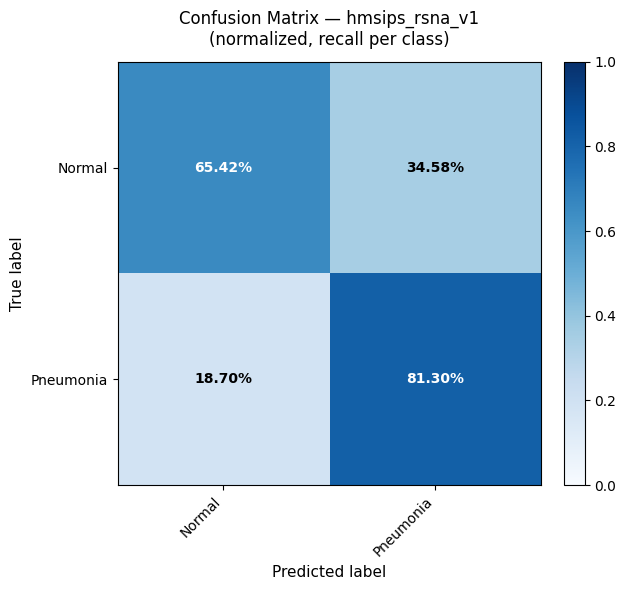


Classification Report
              precision    recall  f1-score   support

      Normal       0.92      0.65      0.77      5176
   Pneumonia       0.41      0.81      0.54      1503

    accuracy                           0.69      6679
   macro avg       0.66      0.73      0.65      6679
weighted avg       0.81      0.69      0.72      6679


Inférence test[0] :
  Probs  : {'pneumonia': array([0.2835874, 0.7164126], dtype=float32)}
  Prédit : {'pneumonia': 1} | Réel : 1
  Patches fins             : 10
  Zones grossières retenues : 4


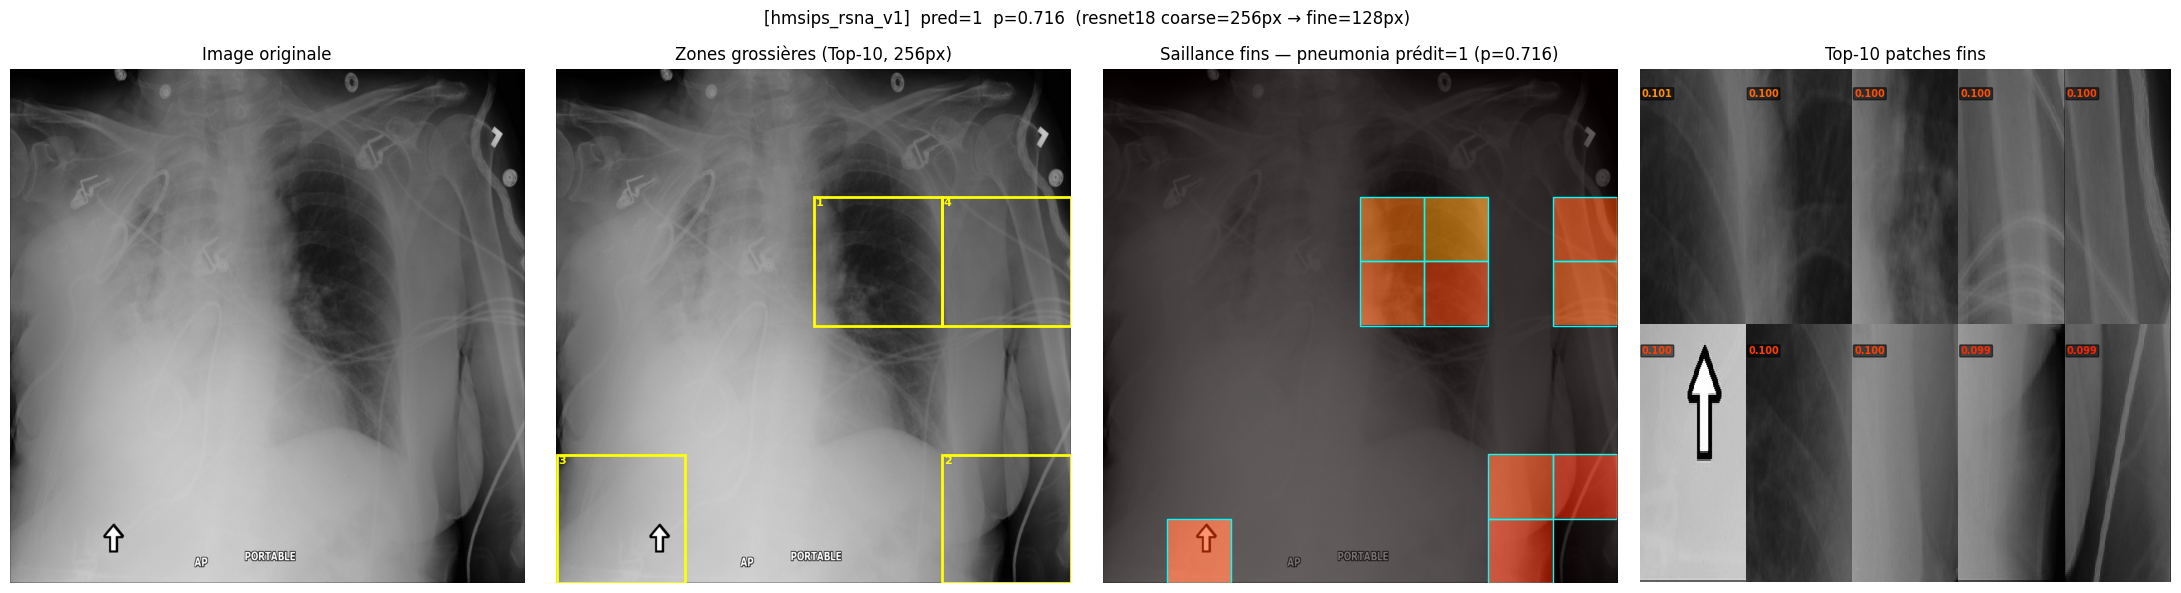

  Sauvegardé : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_saliency_00_img5238.png
  Patches    : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_patches_00_img5238.npy
  Sauvegardé : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_saliency_01_img912.png
  Patches    : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_patches_01_img912.npy
  Sauvegardé : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_saliency_02_img204.png
  Patches    : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_patches_02_img204.npy
  Sauvegardé : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_saliency_03_img6074.png
  Patches    : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_patches_03_img6074.npy
  Sauvegardé : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_saliency_04_img2253.png
  Patches    : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_patches_04_img2253.npy
CSV : /kaggle/working/hmsips/rsna/saliency/hmsips_rsna_v1_saliency.csv  (50 lignes)

CO₂ total     

In [18]:
# ============================================================
# STEP — Runner H-MSIPS (RSNA)
# ============================================================
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

# ── 1. Enregistrement DataFactory ────────────────────────────
DataFactory._registry["hmsips_rsna"] = RSNADatasetHMSIPS
print(f"DataFactory registry : {list(DataFactory._registry.keys())}")

# ── 2. Seeds ─────────────────────────────────────────────────
torch.manual_seed(hmsips_rsna_conf.seed)
np.random.seed(hmsips_rsna_conf.seed)

# ── 3. Chemin de sauvegarde ──────────────────────────────────
SAVE_PATH = "/kaggle/working/hmsips/rsna"
os.makedirs(SAVE_PATH, exist_ok=True)
RUN_NAME = "hmsips_rsna_v1"

# ── 4. Datasets ──────────────────────────────────────────────
ds_train = RSNADatasetHMSIPS(hmsips_rsna_conf, train=True)
ds_test  = RSNADatasetHMSIPS(hmsips_rsna_conf, train=False)

# ── 5. WeightedRandomSampler ─────────────────────────────────
labels_train = np.array([ds_train[i]['pneumonia']
                         for i in range(len(ds_train))])
n_pos   = labels_train.sum()
n_neg   = len(labels_train) - n_pos
w_pos   = 1.0 / n_pos
w_neg   = 1.0 / n_neg
weights = np.where(labels_train == 1, w_pos, w_neg)

sampler = WeightedRandomSampler(
    weights     = torch.from_numpy(weights).float(),
    num_samples = len(weights),
    replacement = True
)

print(f"\nWeightedSampler :")
print(f"  n_pos={n_pos}, n_neg={n_neg}, ratio={n_neg/n_pos:.2f}:1")
print(f"  w_pos={w_pos:.6f}, w_neg={w_neg:.6f}")

# ── 6. DataLoaders ───────────────────────────────────────────
train_loader = DataLoader(
    ds_train,
    batch_size         = hmsips_rsna_conf.B_seq,
    sampler            = sampler,
    num_workers        = hmsips_rsna_conf.n_worker,
    pin_memory         = hmsips_rsna_conf.pin_memory,
    persistent_workers = True
)
test_loader = DataLoader(
    ds_test,
    batch_size         = hmsips_rsna_conf.B_seq,
    shuffle            = False,
    num_workers        = hmsips_rsna_conf.n_worker,
    pin_memory         = hmsips_rsna_conf.pin_memory,
    persistent_workers = True
)

print(f"\nDataLoaders :")
print(f"  train batches : {len(train_loader)}")
print(f"  test  batches : {len(test_loader)}")

# ── 7. Modèle + Engine ───────────────────────────────────────
net    = HMSIPSNet(DEVICE, hmsips_rsna_conf)
engine = UniversalEngineHMSIPS(
    net, hmsips_rsna_conf, DEVICE,
    run_name=RUN_NAME)
engine.summary()

# ── 8. Entraînement (avec tracking CO₂) ──────────────────────
history = engine.fit(train_loader, test_loader)
engine.summary()

# ── 9. Sauvegardes ───────────────────────────────────────────
engine.save(f"{SAVE_PATH}/{RUN_NAME}.pt")
engine.save_weights(f"{SAVE_PATH}/{RUN_NAME}_weights.pt")
engine.save_history(f"{SAVE_PATH}/{RUN_NAME}_history.json")
engine.log_experiment(SAVE_PATH)

print(f"\nFichiers sauvegardés :")
for f in sorted(os.listdir(SAVE_PATH)):
    size = os.path.getsize(f"{SAVE_PATH}/{f}") / 1e6
    print(f"  {f}  —  {size:.1f} MB")

# ── 10. Matrice de confusion ─────────────────────────────────
cm = engine.plot_confusion_matrix(
    test_loader,
    class_names=['Normal', 'Pneumonia'],
    normalize=True,
    save_path=f"{SAVE_PATH}/{RUN_NAME}_confusion_matrix.png"
)

# ── 11. Inférence + saillance sur un exemple ─────────────────
sample    = ds_test[0]
img_check = sample['input']   # (1, 1024, 1024)

result = engine.predict(img_check, return_patches=True)
print(f"\nInférence test[0] :")
print(f"  Probs  : {result['probs']}")
print(f"  Prédit : {result['label']} | Réel : {sample['pneumonia']}")
print(f"  Patches fins             : {result['fine_coords'].shape[0]}")
print(f"  Zones grossières retenues : {result['coarse_coords'].shape[0]}")
engine.show_saliency(img_check, result)

# ── 12. Saillance sur N exemples du test set ─────────────────
save_dir, csv_path = engine.save_saliency(
    dataset  = ds_test,
    save_dir = f"{SAVE_PATH}/saliency",
    n_images = 5,
    seed     = 42
)

# ── 13. Affichage CO₂ total ──────────────────────────────────
emissions = [e for e in engine.history.get("emissions", []) if e is not None]
if emissions:
    print(f"\nCO₂ total      : {sum(emissions):.6f} kg")
    print(f"CO₂ par époque : {sum(emissions)/len(emissions):.6f} kg")
else:
    print("\nCO₂ : non mesuré (codecarbon indisponible)")